# Data Understanding

In [ ]:
#import dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

#load dataset
df = pd.read_csv('/content/drive/MyDrive/Distribusi_Pupuk_Jatim_2023-2025 fix.csv')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#data understanding - collect initial data

print(f"Ukuran Dataset: {df.shape[0]} baris, {df.shape[1]} kolom.")

print("Kolom: ", df.columns.tolist())

#convert data yang harusnya numeric
kolom_numeric = [
    'luas_panen_kedelai',
    'produksi_kedelai_ton',]

def clean_and_convert(series):
    series = series.astype(str)
    series = series.str.replace(',', '.')
    series = series.str.strip()
    return pd.to_numeric(series, errors='coerce')

df[kolom_numeric] = df[kolom_numeric].apply(clean_and_convert)

print("\nTipe data per kolom:")
print(df.dtypes)


print("\nInfo Dataset: ")
df.head()

Ukuran Dataset: 1368 baris, 19 kolom.
Kolom:  ['kabupaten', 'bulan', 'tahun', 'alokasi_urea', 'distribusi_urea', 'alokasi_organik', 'distribusi_organik', 'alokasi_za', 'distribusi_za', 'alokasi_NPK', 'distribusi_NPK', 'curah_hujan', 'suhu', 'luas_panen_padi', 'produksi_padi_ton', 'luas_panen_jagung', 'produksi_jagung_ton', 'luas_panen_kedelai', 'produksi_kedelai_ton']

Tipe data per kolom:
kabupaten                object
bulan                    object
tahun                     int64
alokasi_urea              int64
distribusi_urea         float64
alokasi_organik           int64
distribusi_organik      float64
alokasi_za              float64
distribusi_za           float64
alokasi_NPK               int64
distribusi_NPK          float64
curah_hujan             float64
suhu                    float64
luas_panen_padi           int64
produksi_padi_ton         int64
luas_panen_jagung         int64
produksi_jagung_ton       int64
luas_panen_kedelai      float64
produksi_kedelai_ton    float64

,kabupaten,bulan,tahun,alokasi_urea,distribusi_urea,alokasi_organik,distribusi_organik,alokasi_za,distribusi_za,alokasi_NPK,distribusi_NPK,curah_hujan,suhu,luas_panen_padi,produksi_padi_ton,luas_panen_jagung,produksi_jagung_ton,luas_panen_kedelai,produksi_kedelai_ton
0,Bangkalan,Januari,2023,22027,1820.5,0,0.0,0.0,0.0,13946,768.4,8.72,26.64,7370,38471,1678,9580,12.79,21.88
1,Bangkalan,Februari,2023,22027,3231.9,0,0.0,0.0,0.0,13946,1350.6,11.57,26.34,7370,38397,2806,16217,13.33,22.81
2,Bangkalan,Maret,2023,22027,4686.1,0,0.0,0.0,0.0,13946,2192.7,11.88,26.68,9045,47034,2246,12845,20.57,35.81
3,Bangkalan,April,2023,22027,5744.8,0,0.0,0.0,0.0,13946,2784.6,9.63,27.08,9045,46943,1561,8867,34.76,60.50
4,Bangkalan,Mei,2023,22027,6401.9,0,0.0,0.0,0.0,13946,3193.6,2.90,27.65,5695,29500,1742,10034,74.30,129.34


In [ ]:
#data understanding - verify data quality

#cek duplikasi berdasarkan kombinasi kabupaten+bulan+tahun
duplicates = df.duplicated(subset=['kabupaten', 'bulan', 'tahun'], keep=False)
print(f"\nJumlah duplikat (kabupaten+bulan+tahun): {duplicates.sum()}")
if duplicates.sum() > 0:
    print("Contoh data duplikat:")
    print(df[duplicates].sort_values(['kabupaten', 'tahun', 'bulan']).head(10))
else:
    print("Tidak ditemukan data duplikat.")

#hitung missing values per kolom
print("\nMissing values per kolom:")

missing_value = df.isnull().sum()
print(missing_value)

#hitung nilai 0 per kolom numerik
print("\nNilai 0 per kolom:")

numeric_cols = df.select_dtypes(include=[np.number]).columns
zero_counts = (df[numeric_cols] == 0).sum()
zero_df = pd.DataFrame({
    'Jumlah Nilai 0': zero_counts,
    'Persentase (%)': (zero_counts / len(df) * 100).round(2)
})
zero_df = zero_df[zero_df['Jumlah Nilai 0'] > 0].sort_values('Jumlah Nilai 0', ascending=False)

if len(zero_df) > 0:
    print(zero_df)
else:
    print("Tidak ada kolom dengan nilai 0")

# identifikasi gap per kabupaten
print("\nKabupaten dengan data tidak lengkap:")
kabupaten_completeness = df.groupby('kabupaten').size()
incomplete_kab = kabupaten_completeness[kabupaten_completeness < 36]
if len(incomplete_kab) > 0:
    print(f"Jumlah kabupaten tidak lengkap: {len(incomplete_kab)}")
    for kab, count in incomplete_kab.items():
        print(f"  - {kab}: {count} dari 36 periode")
else:
    print("Semua kabupaten memiliki 36 periode data")


Jumlah duplikat (kabupaten+bulan+tahun): 0
Tidak ditemukan data duplikat.

Missing values per kolom:
kabupaten               0
bulan                   0
tahun                   0
alokasi_urea            0
distribusi_urea         0
alokasi_organik         0
distribusi_organik      0
alokasi_za              0
distribusi_za           0
alokasi_NPK             0
distribusi_NPK          0
curah_hujan             0
suhu                    0
luas_panen_padi         0
produksi_padi_ton       0
luas_panen_jagung       0
produksi_jagung_ton     0
luas_panen_kedelai      0
produksi_kedelai_ton    0
dtype: int64

Nilai 0 per kolom:
                    Jumlah Nilai 0  Persentase (%)
distribusi_za                 1296           94.74
alokasi_za                    1272           92.98
distribusi_organik            1027           75.07
alokasi_organik                897           65.57
distribusi_urea                 15            1.10
distribusi_NPK                  10            0.73
alokasi_NPK   

In [ ]:
#data understanding - statistik deskriptif

fitur_pupuk = ['alokasi_urea', 'distribusi_urea', 'alokasi_organik',
               'distribusi_organik', 'alokasi_za', 'distribusi_za',
               'alokasi_NPK', 'distribusi_NPK']
fitur_iklim = ['curah_hujan', 'suhu']
fitur_padi = ['luas_panen_padi', 'produksi_padi_ton']
fitur_jagung = ['luas_panen_jagung', 'produksi_jagung_ton']
fitur_kedelai = ['luas_panen_kedelai', 'produksi_kedelai_ton']

semua_numerik = fitur_pupuk + fitur_iklim + fitur_padi + fitur_jagung + fitur_kedelai

# cek skewness
print("=== SKEWNESS SELURUH FITUR NUMERIK ===")
skew_df = pd.DataFrame({
    'Skewness': df[semua_numerik].skew().sort_values(ascending=False)
})
print(skew_df)
print("\nInterpretasi:")
print("- |Skewness| < 0.5 : approximately symmetric")
print("- 0.5 <= |Skewness| < 1 : moderately skewed")
print("- |Skewness| >= 1 : highly skewed (pertimbangkan log-transform)")

print("\nStatistik deskriptif:")
df.describe()


=== SKEWNESS SELURUH FITUR NUMERIK ===
                       Skewness
distribusi_za         13.967811
alokasi_za            11.595375
distribusi_organik     4.926580
produksi_kedelai_ton   3.076805
luas_panen_kedelai     3.018157
alokasi_organik        2.679612
curah_hujan            1.729716
distribusi_NPK         1.692897
distribusi_urea        1.591553
produksi_jagung_ton    0.981664
luas_panen_jagung      0.860199
alokasi_NPK            0.639039
alokasi_urea           0.633613
produksi_padi_ton      0.333440
luas_panen_padi        0.326120
suhu                  -0.816860

Interpretasi:
- |Skewness| < 0.5 : approximately symmetric
- 0.5 <= |Skewness| < 1 : moderately skewed
- |Skewness| >= 1 : highly skewed (pertimbangkan log-transform)

Statistik deskriptif:


,tahun,alokasi_urea,distribusi_urea,alokasi_organik,distribusi_organik,alokasi_za,distribusi_za,alokasi_NPK,distribusi_NPK,curah_hujan,suhu,luas_panen_padi,produksi_padi_ton,luas_panen_jagung,produksi_jagung_ton,luas_panen_kedelai,produksi_kedelai_ton
count,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000
mean,2024.000000,24994.106725,12043.684474,2061.959795,604.844759,106.793860,9.569020,18770.660819,8992.462807,5.794108,26.680877,6311.415205,34579.476608,1735.059211,10451.111842,49.042054,84.064335
std,0.816795,19507.680439,13423.679690,4845.451952,2166.819851,874.667332,89.934814,15005.607032,10458.997530,5.396264,1.605158,2510.327073,13983.244539,1420.587913,8910.585314,88.691406,155.257506
min,2023.000000,139.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.110000,1870.000000,9406.000000,43.000000,232.000000,0.010000,0.010000
25%,2023.000000,8386.000000,701.550000,0.000000,0.000000,0.000000,0.000000,4306.000000,703.525000,1.350000,25.950000,4310.000000,23495.750000,238.500000,1341.500000,1.347500,2.175000
50%,2024.000000,25134.000000,7854.500000,0.000000,0.000000,0.000000,0.000000,18596.000000,5441.550000,4.420000,26.800000,6158.500000,33657.000000,1602.000000,9220.000000,11.180000,18.340000
75%,2025.000000,33591.000000,18902.100000,618.000000,0.000000,0.000000,0.000000,27279.000000,13562.500000,9.220000,27.642500,8073.000000,44443.250000,2589.500000,15896.750000,52.650000,86.862500
max,2025.000000,77733.000000,74006.390000,22269.000000,18671.880000,15687.000000,1714.660000,59679.000000,58512.650000,51.340000,30.510000,12319.000000,70341.000000,8307.000000,52667.000000,730.170000,1260.100000


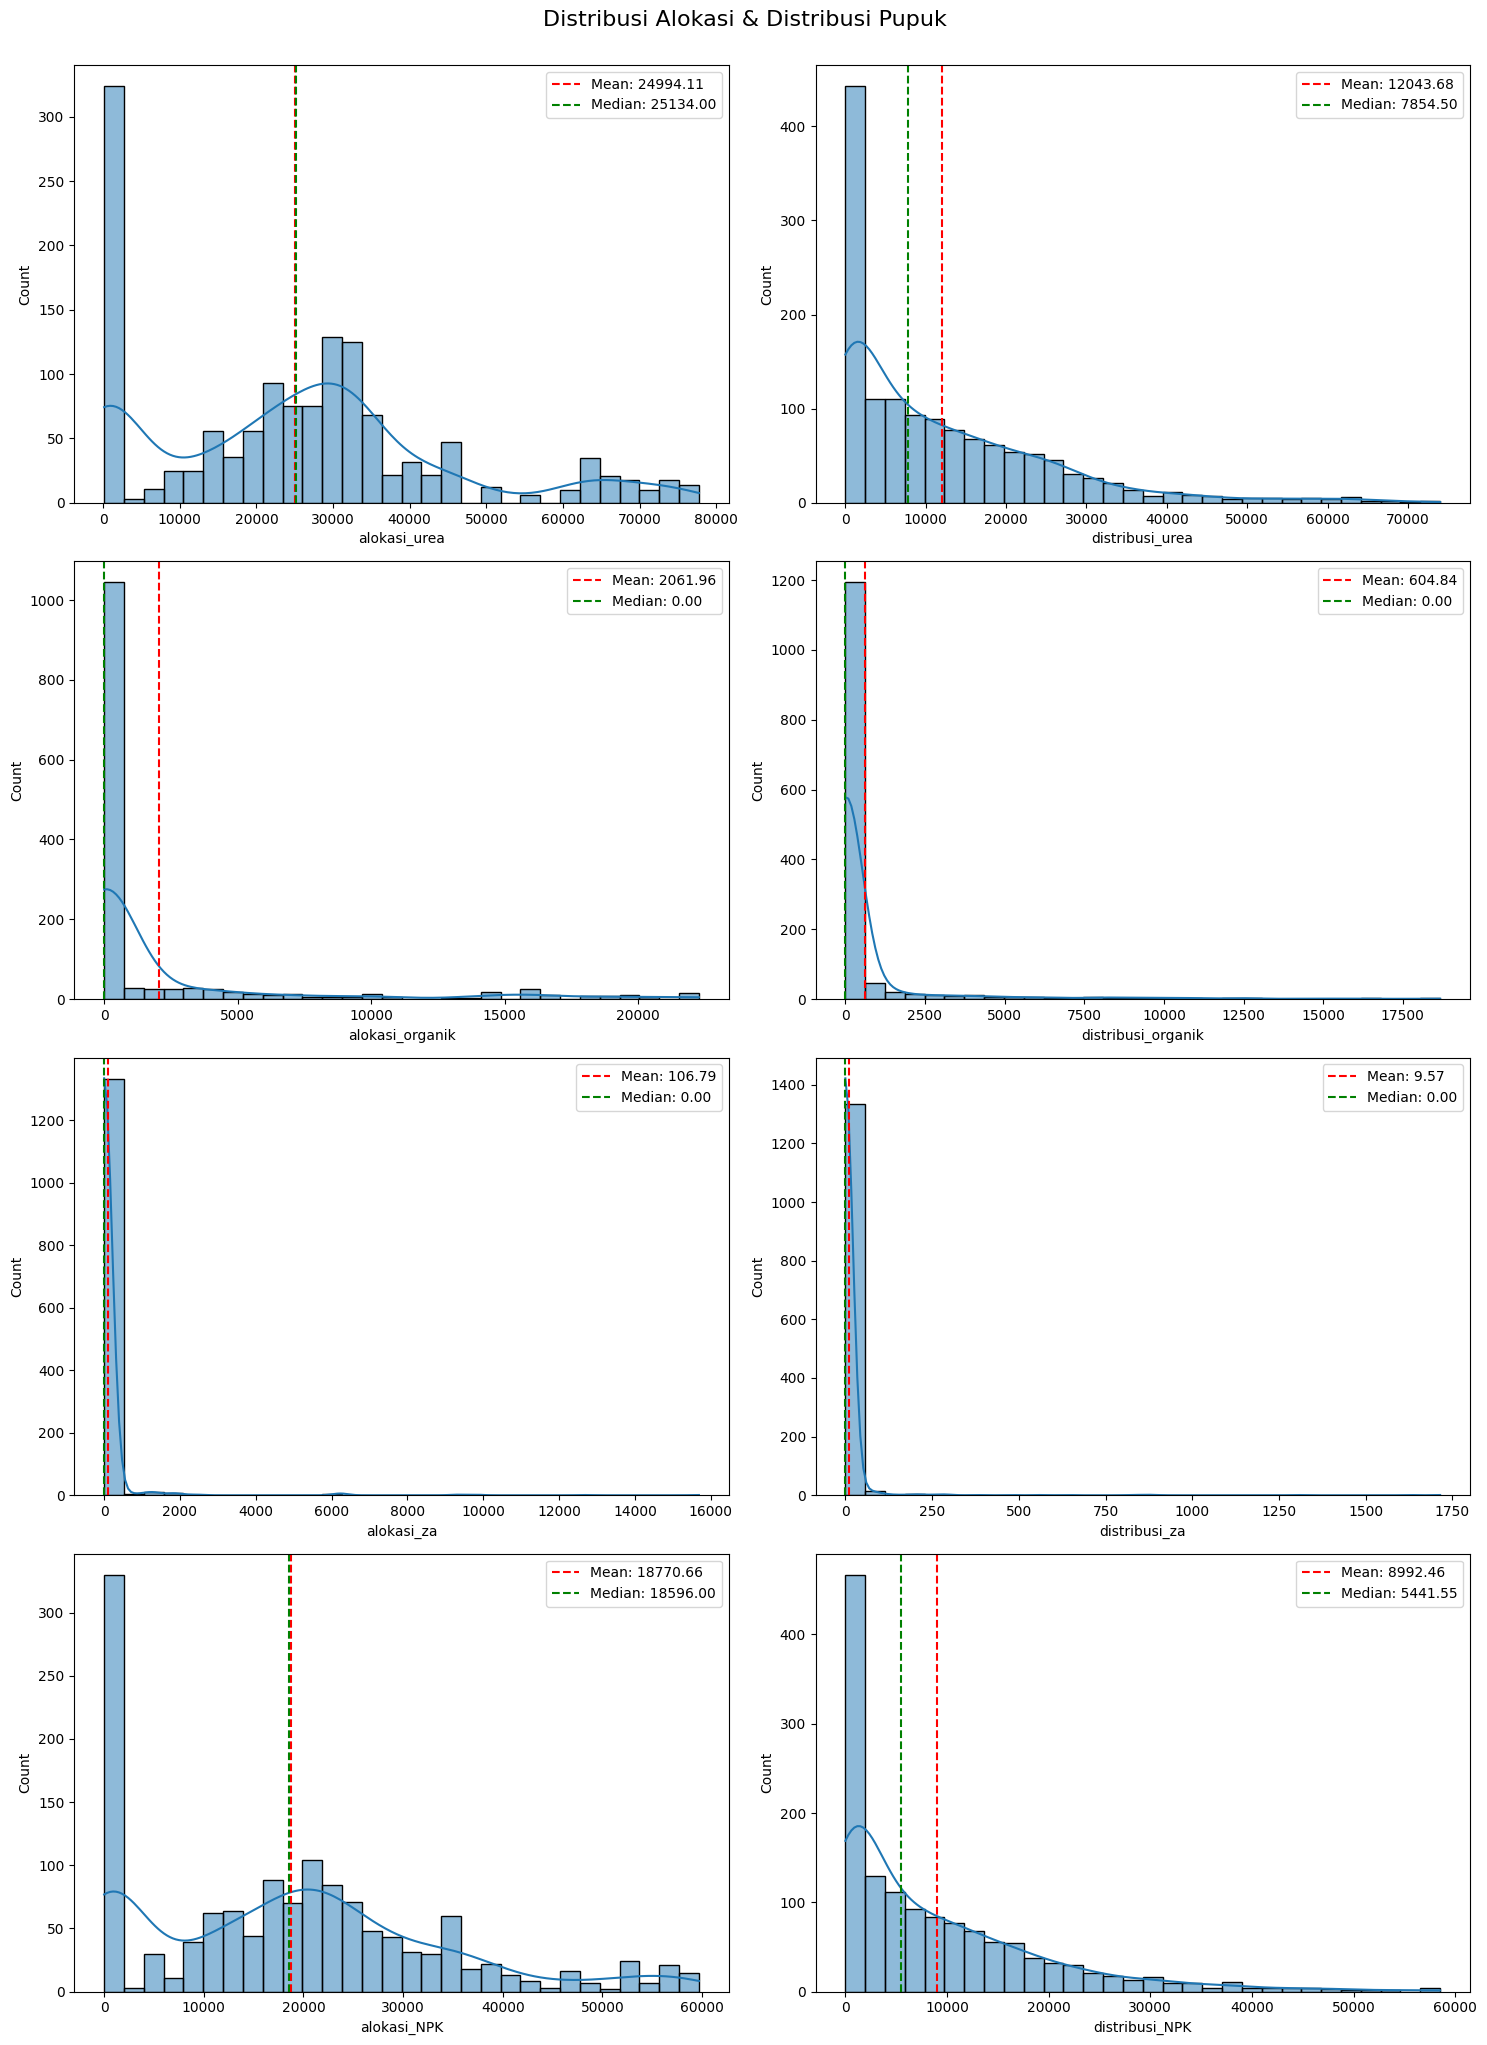

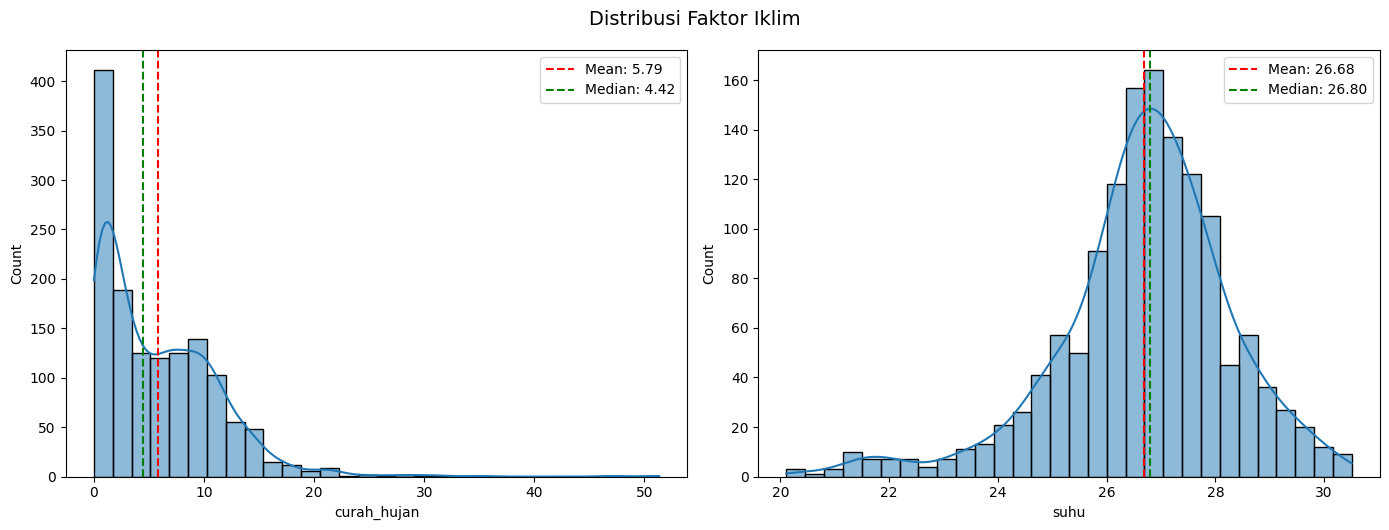

In [ ]:
#data understanding - Exploratory Data Analysis (EDA) - analisis distribusi fitur

#distribusi pupuk
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(fitur_pupuk):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)

    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Distribusi Alokasi & Distribusi Pupuk', fontsize=16, y=1.02)
plt.show()


#distribusi iklim
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(fitur_iklim):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Distribusi Faktor Iklim', fontsize=14, y=1.05)
plt.show()

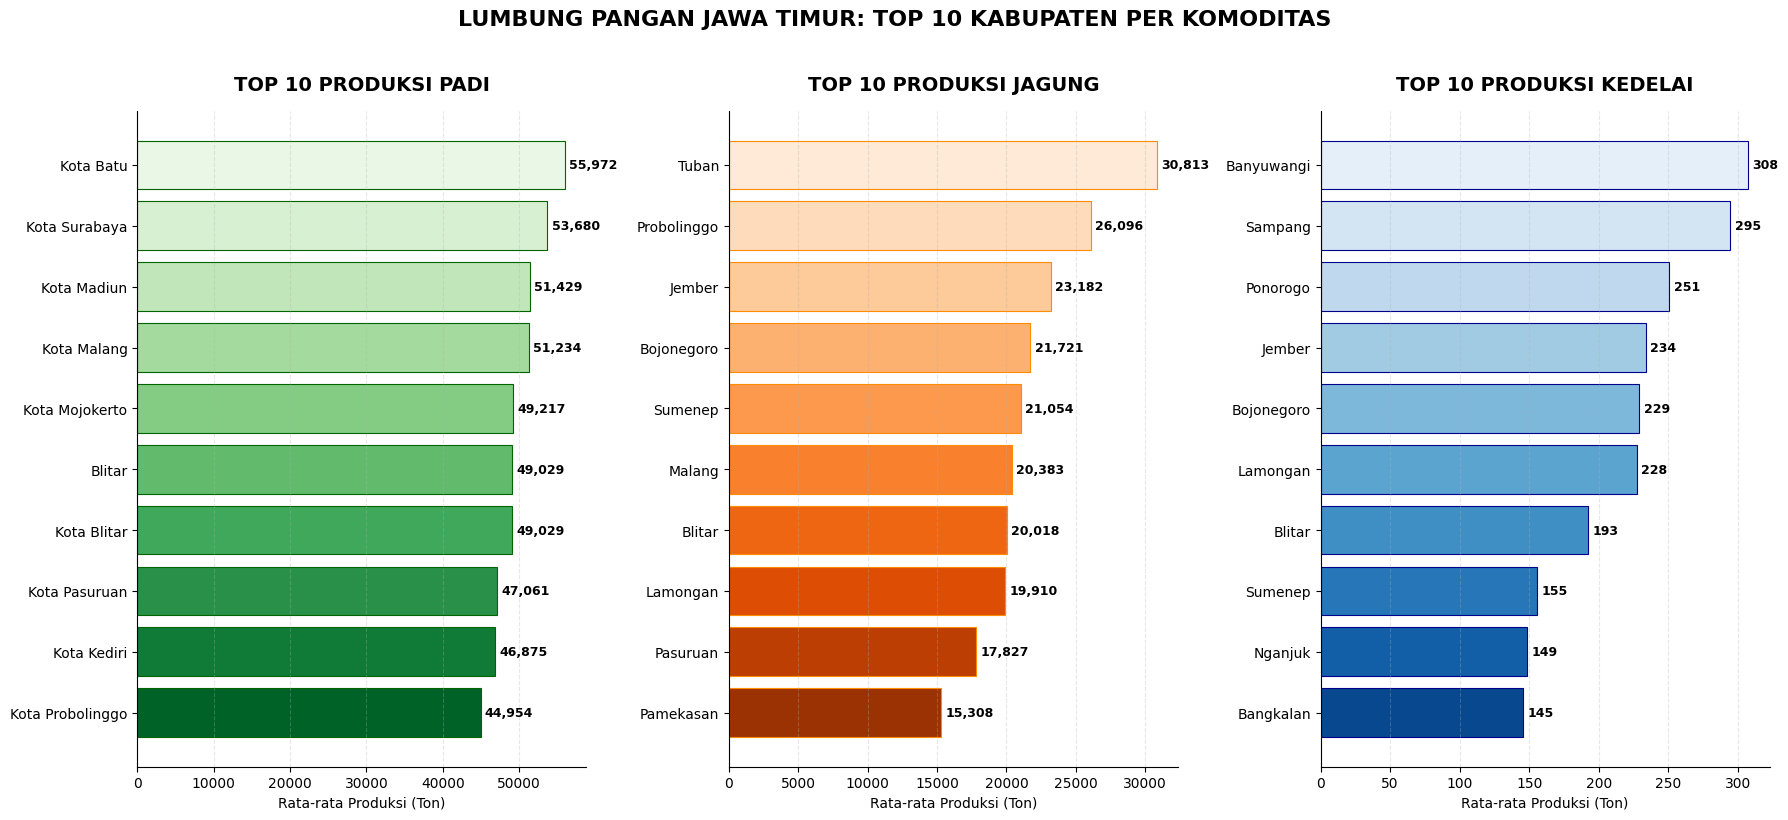

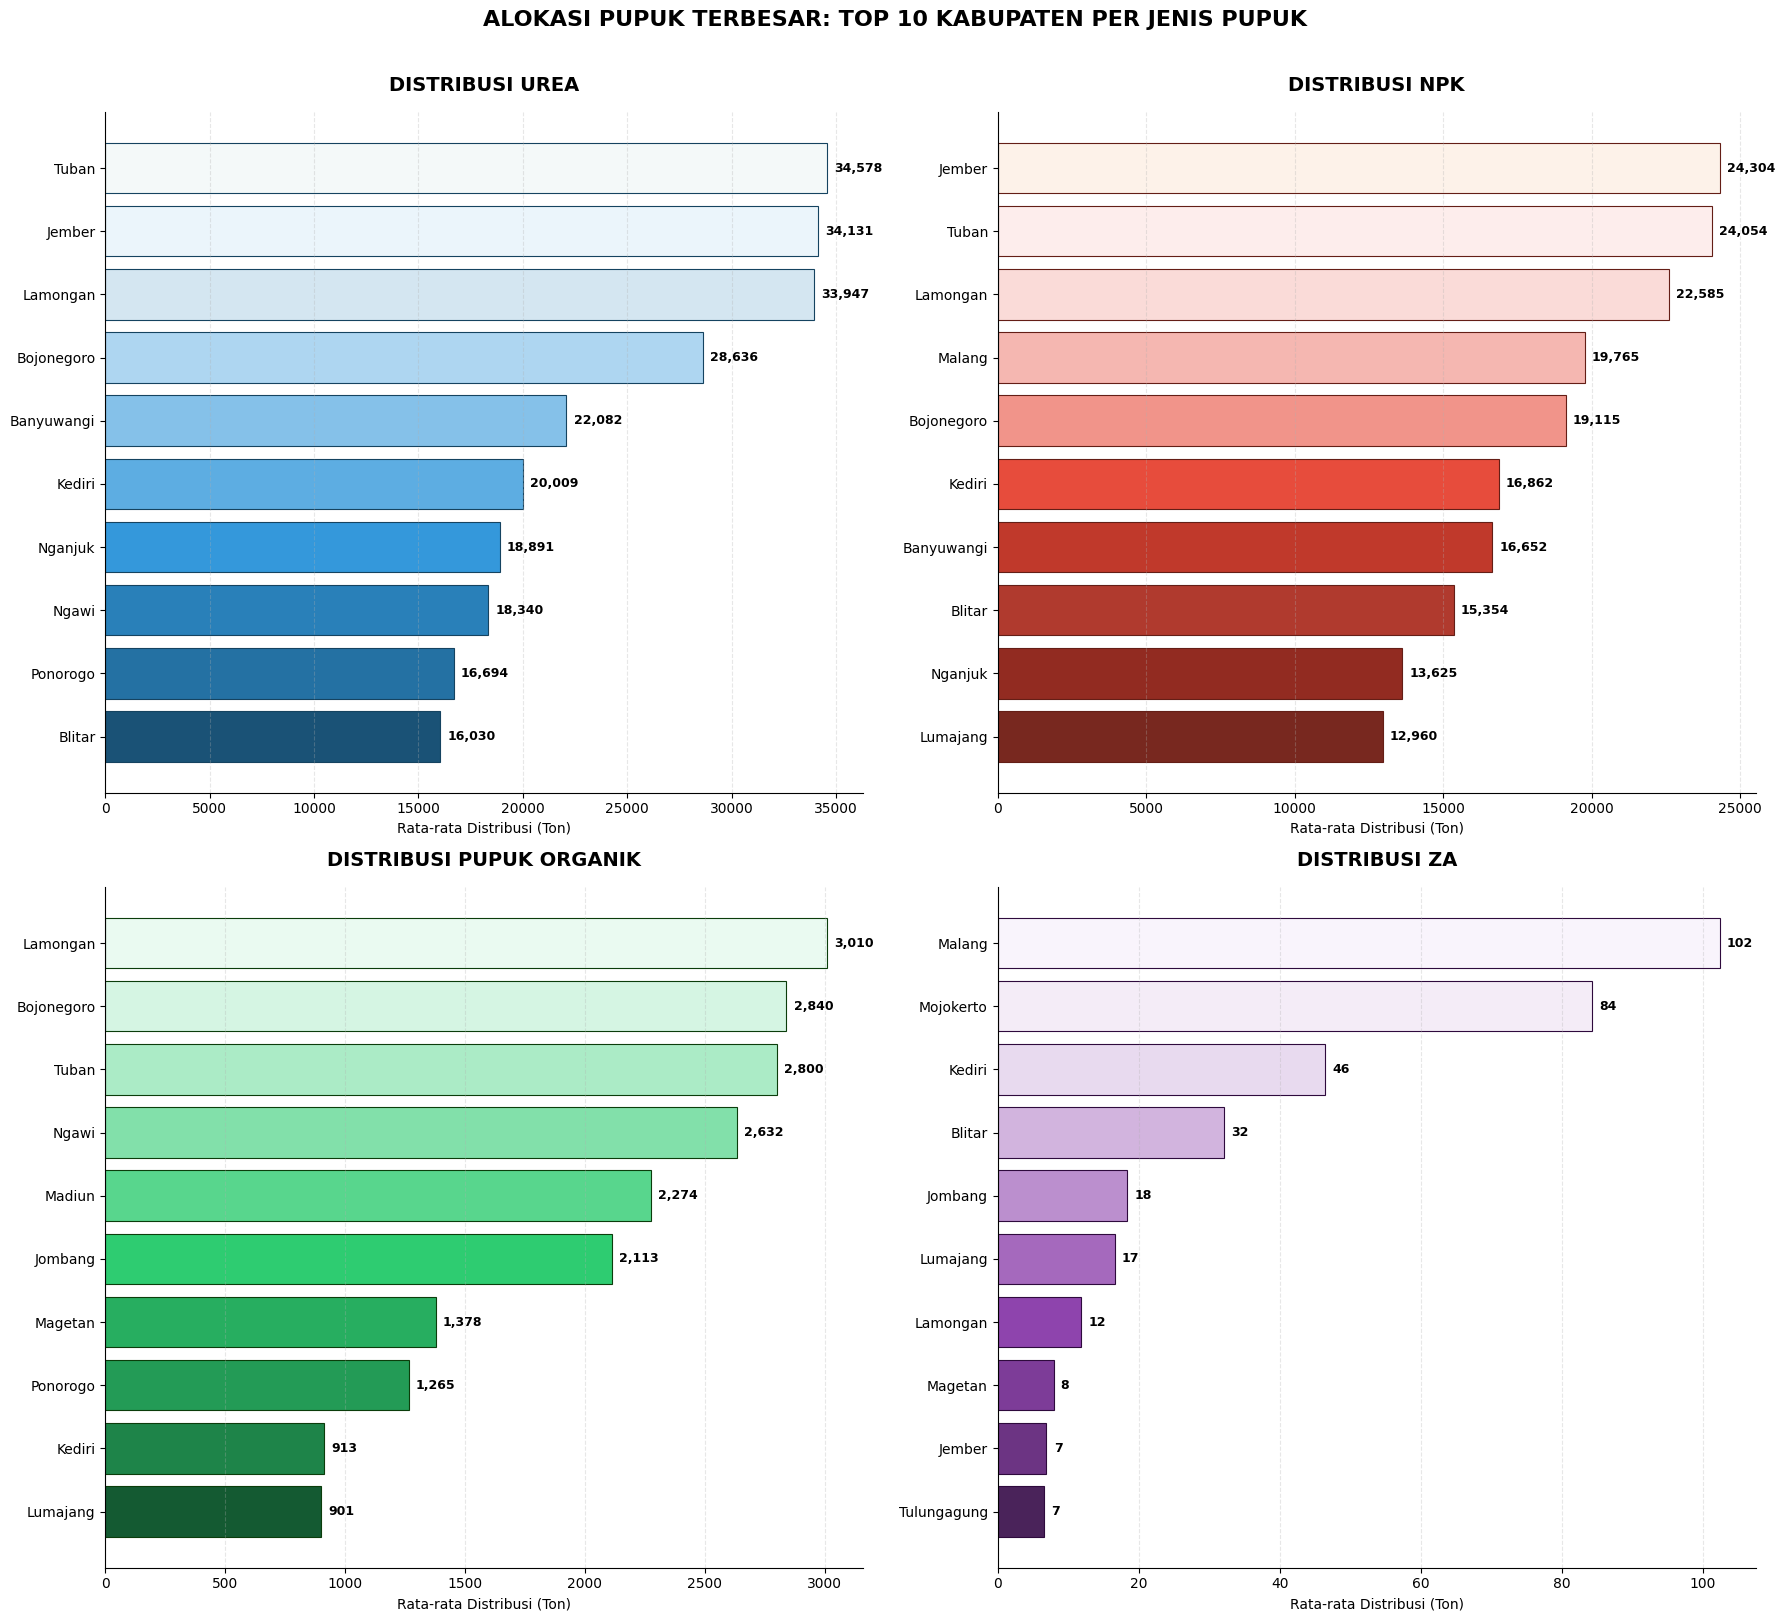

In [ ]:
#data understanding - Exploratory Data Analysis (EDA) - analisis tren spasial


kabupaten_agg = df.groupby('kabupaten').agg({

    'produksi_padi_ton': 'mean',
    'produksi_jagung_ton': 'mean',
    'produksi_kedelai_ton': 'mean',

    'distribusi_urea': 'mean',
    'distribusi_NPK': 'mean',
    'distribusi_organik': 'mean',
    'distribusi_za': 'mean'
}).round(2)


kabupaten_agg = kabupaten_agg.reset_index()


fig, axes = plt.subplots(1, 3, figsize=(18, 8))


colors_padi = sns.color_palette("Greens_r", 10)
colors_jagung = sns.color_palette("Oranges_r", 10)
colors_kedelai = sns.color_palette("Blues_r", 10)

top10_padi = kabupaten_agg.nlargest(10, 'produksi_padi_ton')[['kabupaten', 'produksi_padi_ton']]
top10_jagung = kabupaten_agg.nlargest(10, 'produksi_jagung_ton')[['kabupaten', 'produksi_jagung_ton']]
top10_kedelai = kabupaten_agg.nlargest(10, 'produksi_kedelai_ton')[['kabupaten', 'produksi_kedelai_ton']]

# plot 1 : padi
bars1 = axes[0].barh(top10_padi['kabupaten'][::-1], top10_padi['produksi_padi_ton'][::-1],
                     color=colors_padi, edgecolor='darkgreen', linewidth=0.8)
axes[0].set_title('TOP 10 PRODUKSI PADI', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Rata-rata Produksi (Ton)', fontsize=10)


for bar, val in zip(bars1, top10_padi['produksi_padi_ton'][::-1]):
    axes[0].text(bar.get_width() + max(top10_padi['produksi_padi_ton'])*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')

# plot 2 : jagung
bars2 = axes[1].barh(top10_jagung['kabupaten'][::-1], top10_jagung['produksi_jagung_ton'][::-1],
                     color=colors_jagung, edgecolor='darkorange', linewidth=0.8)
axes[1].set_title('TOP 10 PRODUKSI JAGUNG', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Rata-rata Produksi (Ton)', fontsize=10)

for bar, val in zip(bars2, top10_jagung['produksi_jagung_ton'][::-1]):
    axes[1].text(bar.get_width() + max(top10_jagung['produksi_jagung_ton'])*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')

# plot 3 : kedelai
bars3 = axes[2].barh(top10_kedelai['kabupaten'][::-1], top10_kedelai['produksi_kedelai_ton'][::-1],
                     color=colors_kedelai, edgecolor='darkblue', linewidth=0.8)
axes[2].set_title('TOP 10 PRODUKSI KEDELAI', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Rata-rata Produksi (Ton)', fontsize=10)

for bar, val in zip(bars3, top10_kedelai['produksi_kedelai_ton'][::-1]):
    axes[2].text(bar.get_width() + max(top10_kedelai['produksi_kedelai_ton'])*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')


for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('LUMBUNG PANGAN JAWA TIMUR: TOP 10 KABUPATEN PER KOMODITAS',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 16))


top10_urea = kabupaten_agg.nlargest(10, 'distribusi_urea')[['kabupaten', 'distribusi_urea']]
top10_NPK = kabupaten_agg.nlargest(10, 'distribusi_NPK')[['kabupaten', 'distribusi_NPK']]
top10_organik = kabupaten_agg.nlargest(10, 'distribusi_organik')[['kabupaten', 'distribusi_organik']]
top10_za = kabupaten_agg.nlargest(10, 'distribusi_za')[['kabupaten', 'distribusi_za']]


color_urea = ['#1a5276', '#2471a3', '#2980b9', '#3498db', '#5dade2', '#85c1e9', '#aed6f1', '#d4e6f1', '#ebf5fb', '#f4f9f9']
color_NPK = ['#78281f', '#922b21', '#b03a2e', '#c0392b', '#e74c3c', '#f1948a', '#f5b7b1', '#fadbd8', '#fdedec', '#fdf2e9']
color_organik = ['#145a32', '#1e8449', '#239b56', '#27ae60', '#2ecc71', '#58d68d', '#82e0aa', '#abebc6', '#d5f5e3', '#eafaf1']
color_za = ['#4a235a', '#6c3483', '#7d3c98', '#8e44ad', '#a569bd', '#bb8fce', '#d2b4de', '#e8daef', '#f4ecf7', '#f9f4fc']

# plot 1 : distribusi urea
bars1 = axes[0, 0].barh(top10_urea['kabupaten'][::-1], top10_urea['distribusi_urea'][::-1],
                         color=color_urea, edgecolor='#154360', linewidth=0.8)
axes[0, 0].set_title('DISTRIBUSI UREA', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('Rata-rata Distribusi (Ton)', fontsize=10)
for bar, val in zip(bars1, top10_urea['distribusi_urea'][::-1]):
    axes[0, 0].text(bar.get_width() + max(top10_urea['distribusi_urea'])*0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')

# plot 2 : distribusi npk
bars2 = axes[0, 1].barh(top10_NPK['kabupaten'][::-1], top10_NPK['distribusi_NPK'][::-1],
                         color=color_NPK, edgecolor='#641e16', linewidth=0.8)
axes[0, 1].set_title('DISTRIBUSI NPK', fontsize=14, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Rata-rata Distribusi (Ton)', fontsize=10)
for bar, val in zip(bars2, top10_NPK['distribusi_NPK'][::-1]):
    axes[0, 1].text(bar.get_width() + max(top10_NPK['distribusi_NPK'])*0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')

# plot 3 : distribusi organik
bars3 = axes[1, 0].barh(top10_organik['kabupaten'][::-1], top10_organik['distribusi_organik'][::-1],
                         color=color_organik, edgecolor='#0b3d0b', linewidth=0.8)
axes[1, 0].set_title('DISTRIBUSI PUPUK ORGANIK', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('Rata-rata Distribusi (Ton)', fontsize=10)
for bar, val in zip(bars3, top10_organik['distribusi_organik'][::-1]):
    axes[1, 0].text(bar.get_width() + max(top10_organik['distribusi_organik'])*0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')

# plot 4 : distribusi za
bars4 = axes[1, 1].barh(top10_za['kabupaten'][::-1], top10_za['distribusi_za'][::-1],
                         color=color_za, edgecolor='#2e0a3d', linewidth=0.8)
axes[1, 1].set_title('DISTRIBUSI ZA', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('Rata-rata Distribusi (Ton)', fontsize=10)
for bar, val in zip(bars4, top10_za['distribusi_za'][::-1]):
    axes[1, 1].text(bar.get_width() + max(top10_za['distribusi_za'])*0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')


for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('ALOKASI PUPUK TERBESAR: TOP 10 KABUPATEN PER JENIS PUPUK',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

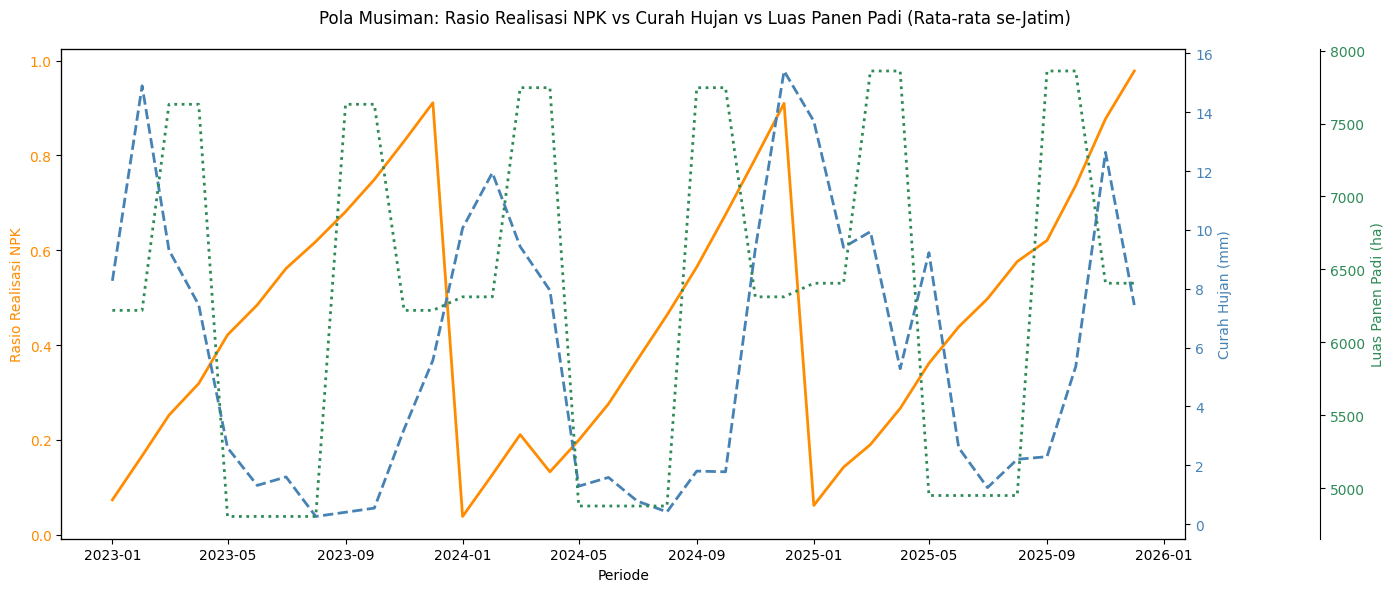

In [ ]:
#data understanding - Exploratory Data Analysis (EDA) - analisis tren temporal
bulan_map = {
    "Januari": 1, "Februari": 2, "Maret": 3, "April": 4,
    "Mei": 5, "Juni": 6, "Juli": 7, "Agustus": 8,
    "September": 9, "Oktober": 10, "November": 11, "Desember": 12,
}
df["bulan_num"] = df["bulan"].map(bulan_map)
df["periode"] = pd.to_datetime(dict(year=df["tahun"], month=df["bulan_num"], day=1))
tren_bulanan = df.groupby("periode").agg(
    rasio_NPK=("rasio_realisasi_NPK", "mean"),
    curah_hujan=("curah_hujan", "mean"),
    luas_panen_padi=("luas_panen_padi", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(tren_bulanan["periode"], tren_bulanan["rasio_NPK"], color="darkorange", label="Rasio Realisasi NPK", linewidth=2)
ax1.set_ylabel("Rasio Realisasi NPK", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax1.set_xlabel("Periode")

ax2 = ax1.twinx()
ax2.plot(tren_bulanan["periode"], tren_bulanan["curah_hujan"], color="steelblue", label="Curah Hujan", linewidth=2, linestyle="--")
ax2.set_ylabel("Curah Hujan (mm)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.12))
ax3.plot(tren_bulanan["periode"], tren_bulanan["luas_panen_padi"], color="seagreen", label="Luas Panen Padi", linewidth=2, linestyle=":")
ax3.set_ylabel("Luas Panen Padi (ha)", color="seagreen")
ax3.tick_params(axis="y", labelcolor="seagreen")

fig.suptitle("Pola Musiman: Rasio Realisasi NPK vs Curah Hujan vs Luas Panen Padi (Rata-rata se-Jatim)")
fig.tight_layout()
plt.savefig("05_pola_musiman_pupuk_iklim_panen.png", dpi=120)
plt.show()



=== Statistik Rasio Realisasi per Jenis Pupuk (setelah perbaikan) ===
       rasio_realisasi_urea  rasio_realisasi_organik  rasio_realisasi_za  \
count           1368.000000               471.000000           96.000000   
mean               0.469260                 0.228367            0.290959   
std                0.279611                 0.254084            0.339791   
min                0.000000                 0.000000            0.000000   
25%                0.227690                 0.000000            0.000477   
50%                0.457014                 0.128473            0.071138   
75%                0.702876                 0.388738            0.569919   
max                0.999550                 1.000000            0.961315   

       rasio_realisasi_NPK  
count          1362.000000  
mean              0.461670  
std               0.293429  
min               0.000000  
25%               0.198896  
50%               0.435884  
75%               0.705984  
max         

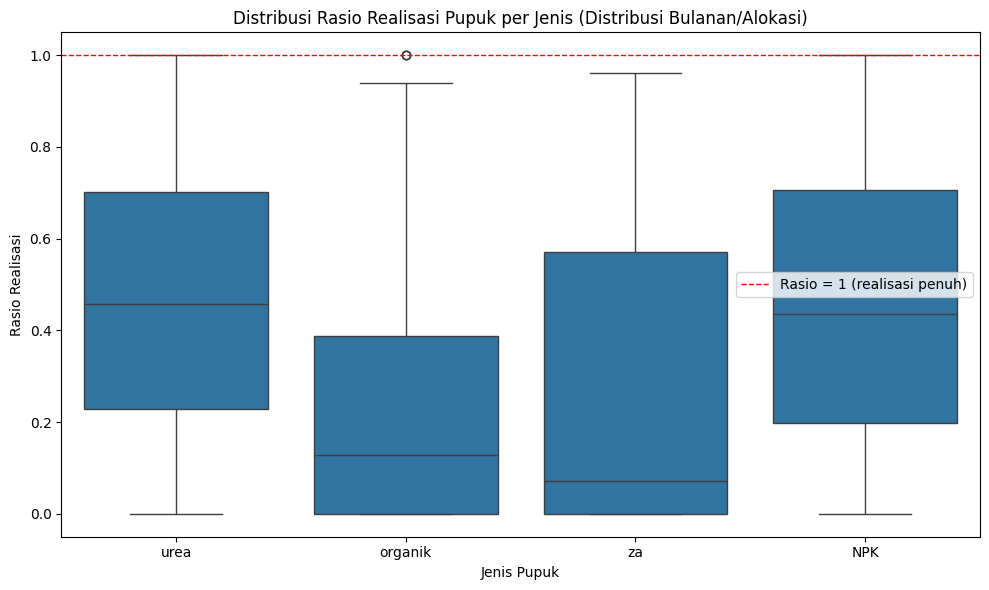

In [ ]:
#data understanding - Exploratory Data Analysis (EDA) - rasio realisasi
jenis_pupuk = ["urea", "organik", "za", "NPK"]

for jp in jenis_pupuk:
    alokasi_col = f"alokasi_{jp}"
    distribusi_col = f"distribusi_{jp}"
    rasio_col = f"rasio_realisasi_{jp}"
    df[rasio_col] = np.where(
        df[alokasi_col] > 0,
        df[distribusi_col] / df[alokasi_col],
        np.nan,
    )

rasio_cols = [f"rasio_realisasi_{jp}" for jp in jenis_pupuk]

print("\n=== Statistik Rasio Realisasi per Jenis Pupuk (setelah perbaikan) ===")
print(df[rasio_cols].describe())

for col in rasio_cols:
    n_anomali = (df[col] > 1).sum()
    n_valid = df[col].notna().sum()
    print(f"{col}: rasio > 1 = {n_anomali} dari {n_valid} baris valid ({n_anomali/n_valid*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
df_melt = df.melt(value_vars=rasio_cols, var_name="jenis_pupuk", value_name="rasio")
df_melt["jenis_pupuk"] = df_melt["jenis_pupuk"].str.replace("rasio_realisasi_", "")

sns.boxplot(data=df_melt[df_melt["rasio"] <= 3], x="jenis_pupuk", y="rasio", ax=ax)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Rasio = 1 (realisasi penuh)")
ax.set_title("Distribusi Rasio Realisasi Pupuk per Jenis (Distribusi Bulanan/Alokasi)")
ax.set_xlabel("Jenis Pupuk")
ax.set_ylabel("Rasio Realisasi")
ax.legend()
plt.tight_layout()
plt.savefig("01_boxplot_rasio_realisasi.png", dpi=120)
plt.show()

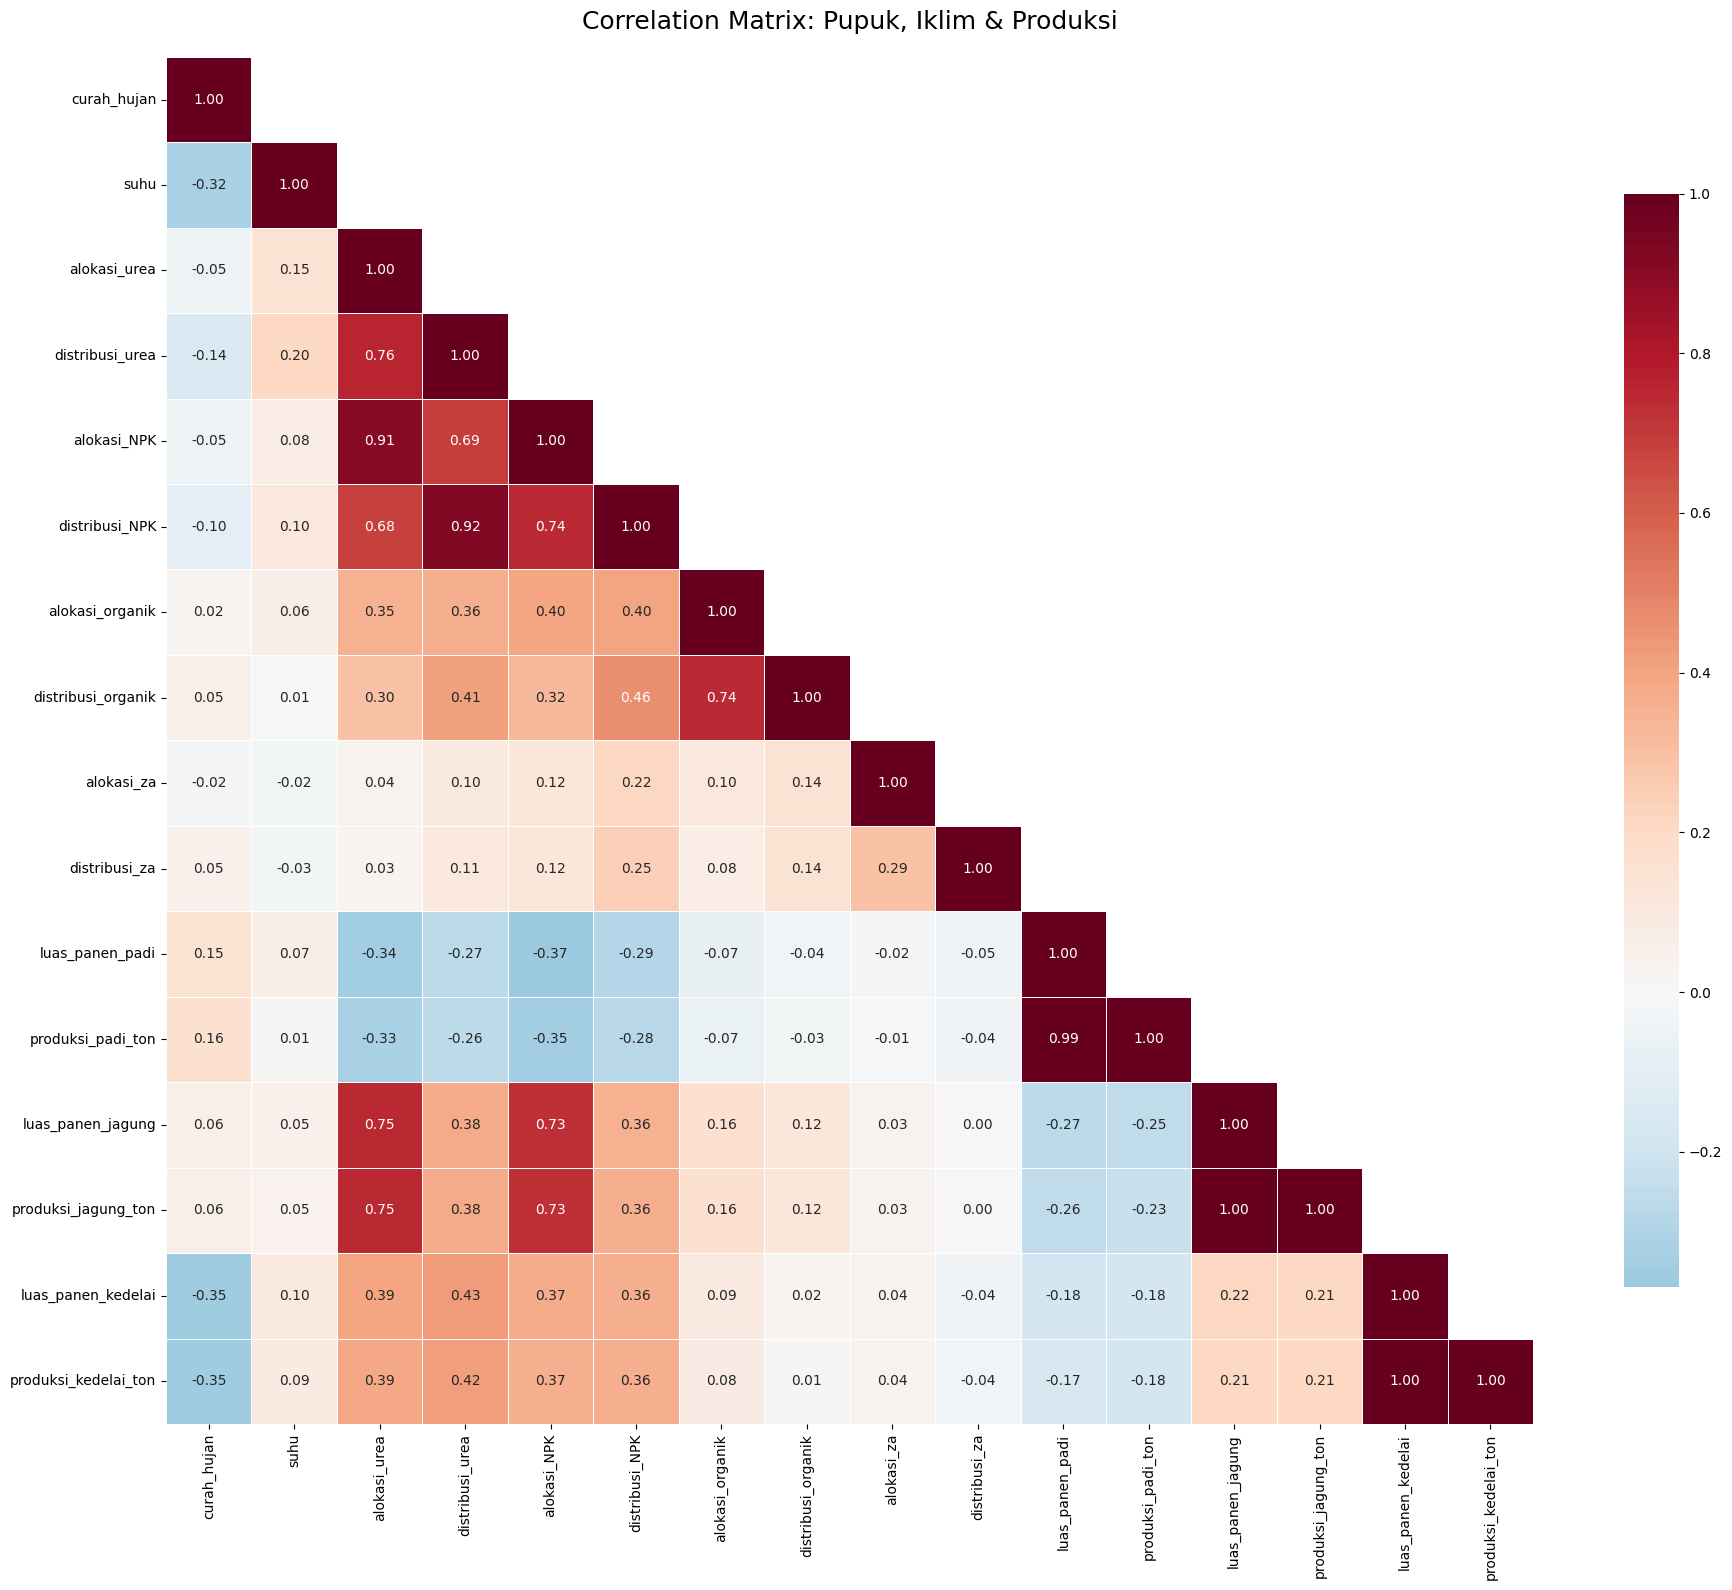

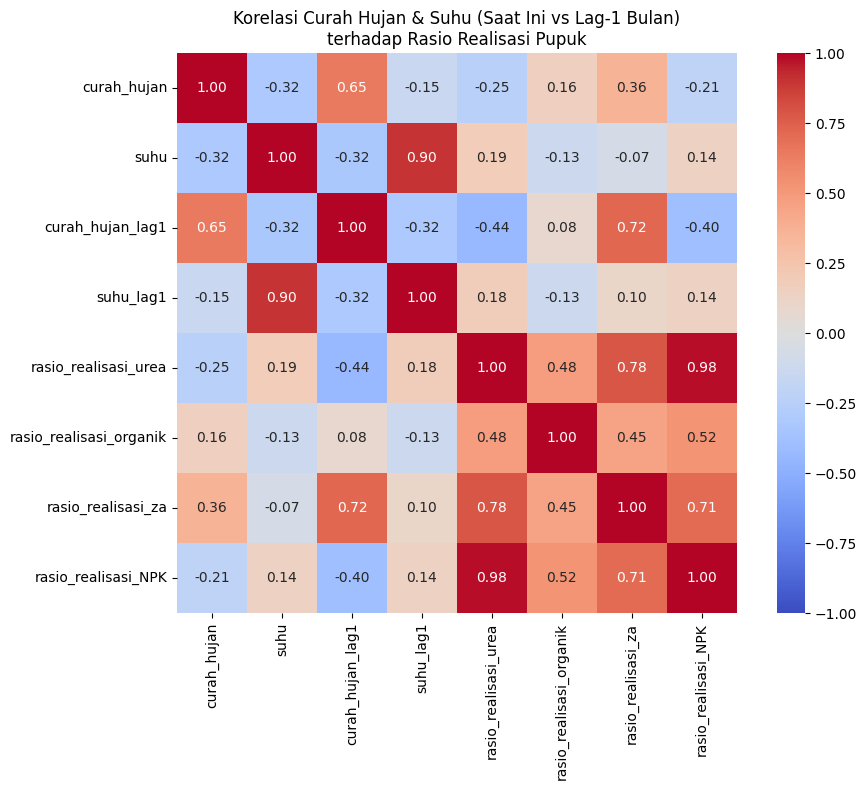


=== Korelasi iklim (current & lag-1) vs rasio realisasi ===
                  rasio_realisasi_urea  rasio_realisasi_organik  \
curah_hujan                  -0.247661                 0.161923   
suhu                          0.185326                -0.125059   
curah_hujan_lag1             -0.437087                 0.082996   
suhu_lag1                     0.177409                -0.125133   

                  rasio_realisasi_za  rasio_realisasi_NPK  
curah_hujan                 0.363639            -0.205493  
suhu                       -0.067538             0.141438  
curah_hujan_lag1            0.724442            -0.397814  
suhu_lag1                   0.101637             0.135478  


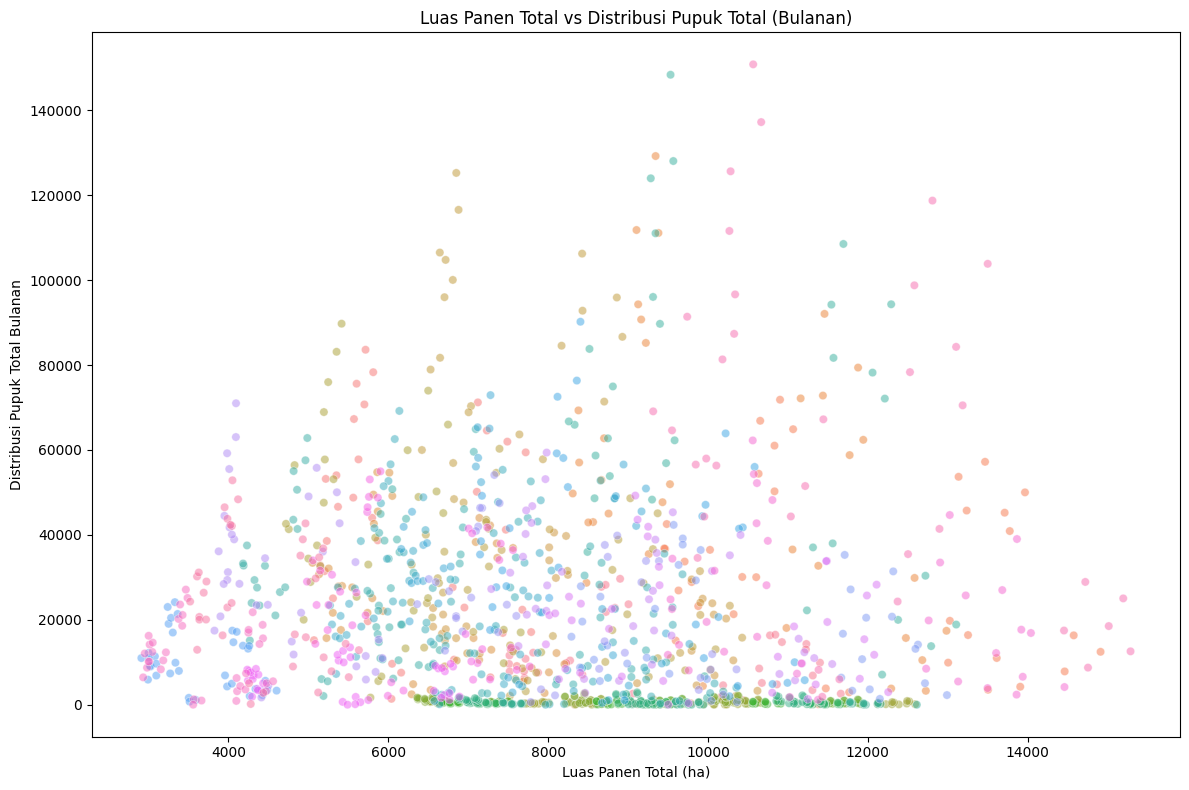

In [ ]:
#data understanding - Exploratory Data Analysis (EDA) - analisis kolerasi fitur

korelasi_cols = [
    'curah_hujan', 'suhu',
    'alokasi_urea', 'distribusi_urea',
    'alokasi_NPK', 'distribusi_NPK',
    'alokasi_organik', 'distribusi_organik',
    'alokasi_za', 'distribusi_za',
    'luas_panen_padi', 'produksi_padi_ton',
    'luas_panen_jagung', 'produksi_jagung_ton',
    'luas_panen_kedelai', 'produksi_kedelai_ton'
]


corr_matrix = df[korelasi_cols].corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Pupuk, Iklim & Produksi', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

#kolerasi iklim dengan rasio realisasi
df["curah_hujan_lag1"] = df.groupby("kabupaten")["curah_hujan"].shift(1)
df["suhu_lag1"] = df.groupby("kabupaten")["suhu"].shift(1)

fitur_korelasi = ["curah_hujan", "suhu", "curah_hujan_lag1", "suhu_lag1"] + rasio_cols
corr_matrix = df[fitur_korelasi].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Korelasi Curah Hujan & Suhu (Saat Ini vs Lag-1 Bulan)\nterhadap Rasio Realisasi Pupuk")
plt.tight_layout()
plt.show()

print("\n=== Korelasi iklim (current & lag-1) vs rasio realisasi ===")
print(corr_matrix.loc[["curah_hujan", "suhu", "curah_hujan_lag1", "suhu_lag1"], rasio_cols])

#LUAS PANEN & PRODUKTIVITAS vs VOLUME DISTRIBUSI PUPUK (BULANAN)
df["luas_panen_total"] = df["luas_panen_padi"] + df["luas_panen_jagung"] + df["luas_panen_kedelai"]
df["distribusi_total_bulanan"] = (
    df["distribusi_urea"] + df["distribusi_organik"]
    + df["distribusi_za"] + df["distribusi_NPK"]
)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x="luas_panen_total",
    y="distribusi_total_bulanan",
    hue="kabupaten",
    legend=False,
    alpha=0.5
)

plt.title("Luas Panen Total vs Distribusi Pupuk Total (Bulanan)")
plt.xlabel("Luas Panen Total (ha)")
plt.ylabel("Distribusi Pupuk Total Bulanan")

plt.tight_layout()
plt.show()

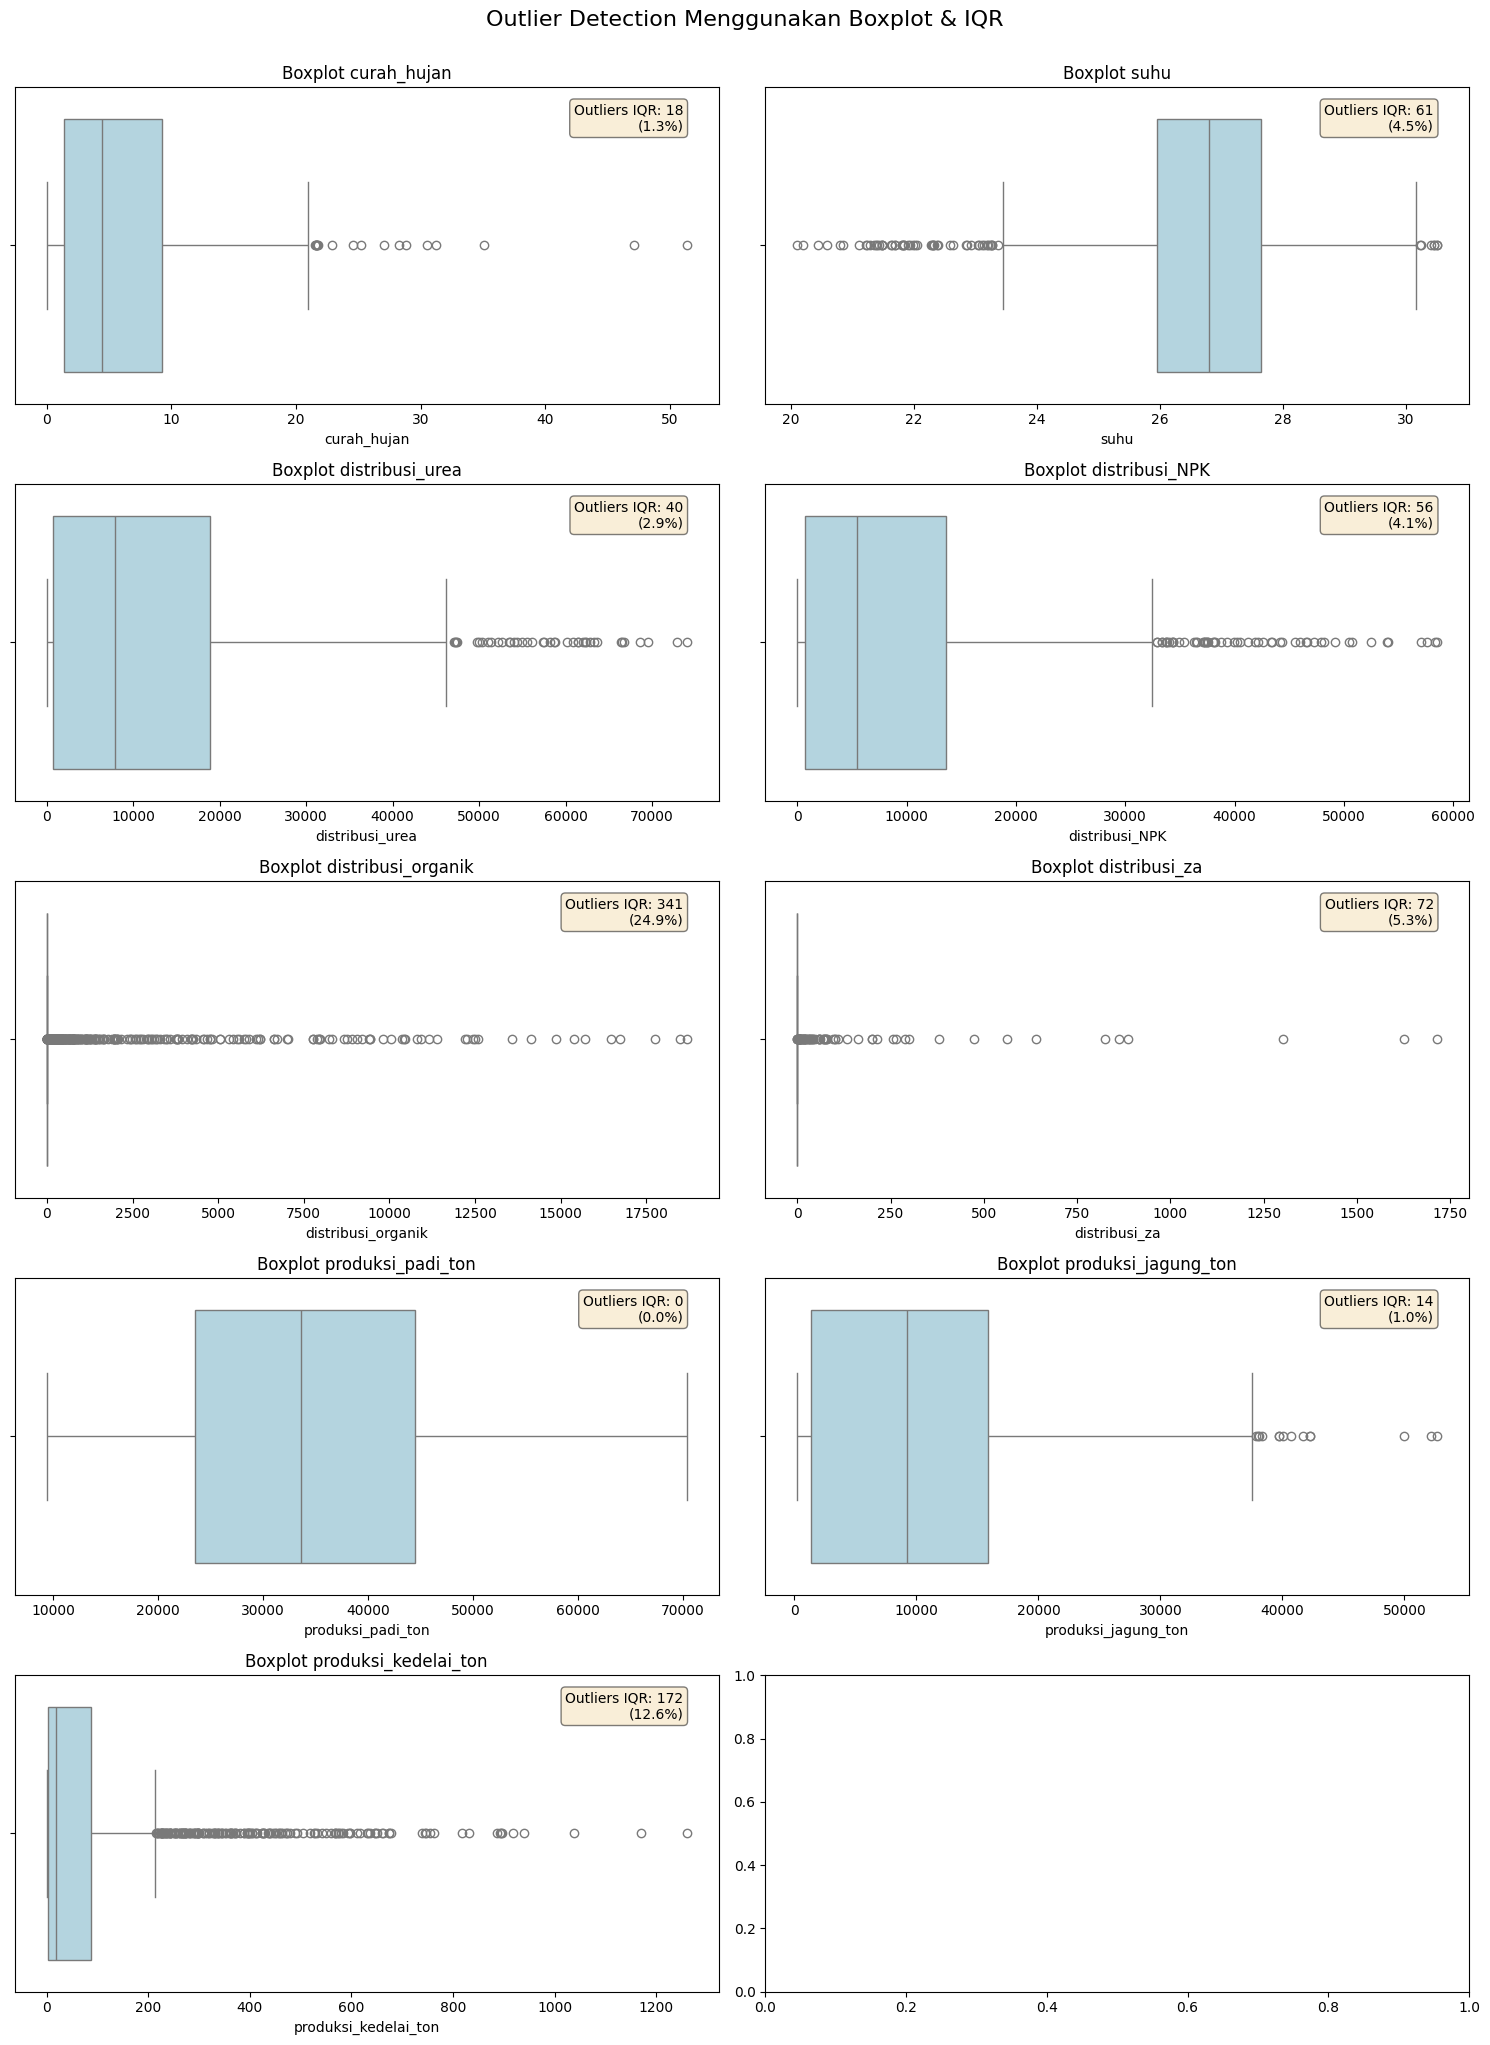

=== ANALISIS OUTLIER IQR ===

Fitur: curah_hujan
  Q1: 1.35 | Q3: 9.22 | IQR: 7.87
  Batas Bawah: -10.46 | Batas Atas: 21.03
  Jumlah Outlier: 18 (1.32%)

  Contoh outlier (5 teratas):
kabupaten    bulan  tahun  curah_hujan
  Magetan Februari   2023        51.34
  Magetan Desember   2024        47.13
  Magetan  Januari   2025        35.05
  Magetan  Januari   2023        31.20
  Magetan Februari   2024        30.54

Fitur: suhu
  Q1: 25.95 | Q3: 27.64 | IQR: 1.69
  Batas Bawah: 23.41 | Batas Atas: 30.18
  Jumlah Outlier: 61 (4.46%)

  Contoh outlier (5 teratas):
     kabupaten   bulan  tahun  suhu
Kota Mojokerto Oktober   2023 30.51
     Mojokerto Oktober   2023 30.51
   Kota Madiun Oktober   2023 30.46
        Madiun Oktober   2023 30.46
         Ngawi Oktober   2023 30.41

Fitur: distribusi_urea
  Q1: 701.55 | Q3: 18902.10 | IQR: 18200.55
  Batas Bawah: -26599.27 | Batas Atas: 46202.92
  Jumlah Outlier: 40 (2.92%)

  Contoh outlier (5 teratas):
kabupaten    bulan  tahun  distribusi_u

In [ ]:
#data understanding - Exploratory Data Analysis (EDA) - outlier & anomaly Detection


fitur_outlier_check = [
    'curah_hujan', 'suhu',
    'distribusi_urea', 'distribusi_NPK', 'distribusi_organik', 'distribusi_za',
    'produksi_padi_ton', 'produksi_jagung_ton', 'produksi_kedelai_ton',
]

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(fitur_outlier_check):
    sns.boxplot(x=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot {col}')


    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

    axes[i].text(0.95, 0.95, f'Outliers IQR: {n_outliers}\n({n_outliers/len(df)*100:.1f}%)',
                transform=axes[i].transAxes, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.suptitle('Outlier Detection Menggunakan Boxplot & IQR', fontsize=16, y=1.02)
plt.show()



def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return {
        'column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_outliers': len(outliers),
        'pct_outliers': len(outliers) / len(df) * 100,
        'outliers_data': outliers[['kabupaten', 'bulan', 'tahun', column]]
    }


print("=== ANALISIS OUTLIER IQR ===\n")
outlier_results = []

for col in fitur_outlier_check:
    result = detect_outliers_iqr(df, col)
    outlier_results.append(result)

    print(f"{'='*60}")
    print(f"Fitur: {col}")
    print(f"  Q1: {result['Q1']:.2f} | Q3: {result['Q3']:.2f} | IQR: {result['IQR']:.2f}")
    print(f"  Batas Bawah: {result['lower_bound']:.2f} | Batas Atas: {result['upper_bound']:.2f}")
    print(f"  Jumlah Outlier: {result['n_outliers']} ({result['pct_outliers']:.2f}%)")


    if result['n_outliers'] > 0:
        print(f"\n  Contoh outlier (5 teratas):")
        outlier_display = result['outliers_data'].nlargest(5, col) if result['outliers_data'][col].dtype in ['float64', 'int64'] else result['outliers_data'].head()
        print(outlier_display[['kabupaten', 'bulan', 'tahun', col]].to_string(index=False))
    print()




# Data Preprocessing

In [100]:


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)


#data loading & cleaning

print("=" * 60)
print("STEP 1: DATA LOADING & INITIAL CLEANING")
print("=" * 60)

df = pd.read_csv('/content/drive/MyDrive/Distribusi_Pupuk_Jatim_2023-2025 fix.csv')
print(f"Shape awal: {df.shape}")

kolom_koma = ["luas_panen_kedelai", "produksi_kedelai_ton"]
for col in kolom_koma:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False).astype(float)

bulan_map = {
    "Januari": 1, "Februari": 2, "Maret": 3, "April": 4,
    "Mei": 5, "Juni": 6, "Juli": 7, "Agustus": 8,
    "September": 9, "Oktober": 10, "November": 11, "Desember": 12,
}
df["bulan_num"] = df["bulan"].map(bulan_map)
df = df.sort_values(["kabupaten", "tahun", "bulan_num"]).reset_index(drop=True)

n_dup = df.duplicated(subset=["kabupaten", "tahun", "bulan_num"]).sum()
print(f"Baris duplikat: {n_dup}")
print(f"Missing value total: {df.isna().sum().sum()}")


#feature selection

print("\n" + "=" * 60)
print("STEP 3: FEATURE SELECTION")
print("=" * 60)

kolom_za_organik = [
    "alokasi_za",
    "distribusi_za",
    "alokasi_organik",
    "distribusi_organik",
]
df = df.drop(columns=kolom_za_organik)
print(f"Drop ZA & organik: {len(kolom_za_organik)} kolom dihapus.")


print("Fitur lag (curah_hujan_lag1, suhu_lag1, rasio_*_lag1) TIDAK dibuat (disederhanakan).")



# 4. FEATURE ENGINEERING feature engineering

print("\n" + "=" * 60)
print("STEP 4: FEATURE ENGINEERING")
print("=" * 60)


for jp in ["urea", "NPK"]:
    df[f"rasio_realisasi_{jp}"] = np.where(
        df[f"alokasi_{jp}"] > 0, df[f"distribusi_{jp}"] / df[f"alokasi_{jp}"], np.nan
    )
print("rasio_realisasi_urea, rasio_realisasi_NPK dibuat.")


df["produktivitas_padi"] = np.where(
    df["luas_panen_padi"] > 0, df["produksi_padi_ton"] / df["luas_panen_padi"], np.nan
)
df["produktivitas_jagung"] = np.where(
    df["luas_panen_jagung"] > 0, df["produksi_jagung_ton"] / df["luas_panen_jagung"], np.nan
)
df["produktivitas_kedelai"] = np.where(
    df["luas_panen_kedelai"] > 0, df["produksi_kedelai_ton"] / df["luas_panen_kedelai"], np.nan
)
print("produktivitas_padi, produktivitas_jagung dibuat.")


df["luas_panen_total"] = df["luas_panen_padi"] + df["luas_panen_jagung"] + df["luas_panen_kedelai"]
df["produksi_total_ton"] = df["produksi_padi_ton"] + df["produksi_jagung_ton"] + df["produksi_kedelai_ton"]
print("luas_panen_total, produksi_total_ton dibuat (meringkas 6 kolom komoditas terpisah).")


df["tipe_wilayah_encoded"] = df["kabupaten"].str.startswith("Kota").astype(int)
print("tipe_wilayah_encoded dibuat (0=kabupaten, 1=kota).")


print("Kolom kabupaten_encoded akan dihitung di STEP 6 (setelah train-test split, cegah leakage).")


df["kuartal"] = df["bulan_num"].apply(lambda m: (m - 1) // 3 + 1)
print("kuartal dibuat (1 kolom musim, ringkas).")

print(f"\nShape setelah feature engineering: {df.shape}")



#outlier handling

print("\n" + "=" * 60)
print("STEP 5: OUTLIER HANDLING")
print("=" * 60)

for jp in ["urea", "NPK"]:
    col = f"rasio_realisasi_{jp}"
    n_ekstrem = (df[col] > 3).sum()
    if n_ekstrem > 0:
        df.loc[df[col] > 3, col] = np.nan
    print(f"{col}: {n_ekstrem} nilai ekstrem (>3) di-set NaN")



#train-test split (time-aware) + frequency encoding kabupaten

print("\n" + "=" * 60)
print("STEP 6: TRAIN-TEST SPLIT & FREQUENCY ENCODING")
print("=" * 60)


df_train = df[df["tahun"].isin([2023, 2024])].copy()
df_test = df[df["tahun"] == 2025].copy()
print(f"Training (2023-2024): {df_train.shape[0]} baris")
print(f"Testing (2025): {df_test.shape[0]} baris")


freq_map = df_train.groupby("kabupaten")["produksi_total_ton"].mean()
df_train["kabupaten_encoded"] = df_train["kabupaten"].map(freq_map)
df_test["kabupaten_encoded"] = df_test["kabupaten"].map(freq_map)
print("kabupaten_encoded dibuat (1 kolom, berbasis rata-rata produksi_total_ton training).")
print("Fitur ini menggantikan 38 kolom one-hot encoding sebelumnya.")



#scaling fitur numerik

print("\n" + "=" * 60)
print("STEP 7: SCALING")
print("=" * 60)


fitur_numerik = [
    "curah_hujan", "suhu",
    "produktivitas_padi", "produktivitas_jagung",
    "produktivitas_kedelai",
    "luas_panen_total", "produksi_total_ton",
    "alokasi_urea", "alokasi_NPK",
    "kabupaten_encoded",
]

scaler = StandardScaler()
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

for col in fitur_numerik:
    median_train = df_train[col].median()
    df_train_scaled[col] = df_train[col].fillna(median_train)
    df_test_scaled[col] = df_test[col].fillna(median_train)

df_train_scaled[fitur_numerik] = scaler.fit_transform(df_train_scaled[fitur_numerik])
df_test_scaled[fitur_numerik] = scaler.transform(df_test_scaled[fitur_numerik])
print(f"Scaling diterapkan pada {len(fitur_numerik)} fitur numerik (fit hanya di training).")



# final feature set summary & export

print("\n" + "=" * 60)
print("STEP 8: FINAL FEATURE SET SUMMARY")
print("=" * 60)

fitur_final = [
    "kabupaten",
    "tahun",
    "bulan_num",

    "alokasi_urea",
    "alokasi_NPK",

    "curah_hujan",
    "suhu",

    "luas_panen_total",
    "produksi_total_ton",

    "produktivitas_padi",
    "produktivitas_jagung",
    "produktivitas_kedelai",

    "kabupaten_encoded",

    "tipe_wilayah_encoded",

    # target klasifikasi
    "rasio_realisasi_urea",
    "rasio_realisasi_NPK",

    # target regresi
    "distribusi_urea",
    "distribusi_NPK"
]

print(f"Total fitur final: {len(fitur_final)} kolom")
print("\nDaftar fitur final:")
for f in fitur_final:
    print(f"  - {f}")


df_train.to_csv("/content/drive/MyDrive/training_unscaled.csv", index=False)
df_test.to_csv("/content/drive/MyDrive/testing_unscaled.csv", index=False)
df_train_scaled.to_csv("/content/drive/MyDrive/distribusi_pupuk_training.csv", index=False)
df_test_scaled.to_csv("/content/drive/MyDrive/distribusi_pupuk_test.csv", index=False)

print(f"\nShape final train_scaled: {df_train_scaled[fitur_final].shape}")
print(f"Shape final test_scaled: {df_test_scaled[fitur_final].shape}")


STEP 1: DATA LOADING & INITIAL CLEANING
Shape awal: (1368, 19)
Baris duplikat: 0
Missing value total: 0

STEP 3: FEATURE SELECTION
Drop ZA & organik: 4 kolom dihapus.
Fitur lag (curah_hujan_lag1, suhu_lag1, rasio_*_lag1) TIDAK dibuat (disederhanakan).

STEP 4: FEATURE ENGINEERING
rasio_realisasi_urea, rasio_realisasi_NPK dibuat.
produktivitas_padi, produktivitas_jagung dibuat.
luas_panen_total, produksi_total_ton dibuat (meringkas 6 kolom komoditas terpisah).
tipe_wilayah_encoded dibuat (0=kabupaten, 1=kota).
Kolom kabupaten_encoded akan dihitung di STEP 6 (setelah train-test split, cegah leakage).
kuartal dibuat (1 kolom musim, ringkas).

Shape setelah feature engineering: (1368, 25)

STEP 5: OUTLIER HANDLING
rasio_realisasi_urea: 0 nilai ekstrem (>3) di-set NaN
rasio_realisasi_NPK: 0 nilai ekstrem (>3) di-set NaN

STEP 6: TRAIN-TEST SPLIT & FREQUENCY ENCODING
Training (2023-2024): 912 baris
Testing (2025): 456 baris
kabupaten_encoded dibuat (1 kolom, berbasis rata-rata produksi_total

# Modelling

In [103]:
# ============================================================
# MODELING - Klasifikasi Tingkat Kebutuhan -> Prediksi Distribusi Pupuk
# Dataset: Distribusi Pupuk Jawa Timur 2023-2025 (hasil preprocessing)
# ============================================================
#
# Arsitektur pipeline:
#   Tahap 1: Bangun composite index "tingkat kebutuhan pupuk" dari gabungan
#            rasio realisasi (urea+NPK rata-rata), luas panen total, curah
#            hujan (BOBOT SAMA: 1/3 each) -> binning 3 kelas
#   Tahap 2: Model KLASIFIKASI memprediksi kelas tersebut dari fitur lain
#            (TANPA rasio realisasi, curah_hujan, luas_panen_total)
#            MENGGUNAKAN DATA SCALED
#   Tahap 3: Hasil klasifikasi -> fitur tambahan untuk model REGRESI
#            MENGGUNAKAN DATA SCALED
#
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
)
from xgboost import XGBClassifier, XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

# ------------------------------------------------------------
# 0. LOAD DATA HASIL PREPROCESSING
# ------------------------------------------------------------
print("=" * 60)
print("STEP 0: LOAD DATA")
print("=" * 60)

# Load unscaled untuk composite index (butuh nilai asli)
train_unscaled = pd.read_csv("/content/drive/MyDrive/training_unscaled.csv")
test_unscaled = pd.read_csv("/content/drive/MyDrive/testing_unscaled.csv")
print(f"Unscaled - Train: {train_unscaled.shape} | Test: {test_unscaled.shape}")

# Load scaled untuk modeling
train_scaled = pd.read_csv("/content/drive/MyDrive/distribusi_pupuk_training.csv")
test_scaled = pd.read_csv("/content/drive/MyDrive/distribusi_pupuk_test.csv")
print(f"Scaled   - Train: {train_scaled.shape} | Test: {test_scaled.shape}")

# Verifikasi kolom
print(f"\nKolom di train_unscaled: {list(train_unscaled.columns)}")
print(f"Kolom di train_scaled  : {list(train_scaled.columns)}")

# ------------------------------------------------------------
# TAHAP 1: COMPOSITE INDEX -> LABEL KLASIFIKASI TINGKAT KEBUTUHAN
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("TAHAP 1: COMPOSITE INDEX & LABEL KLASIFIKASI")
print("=" * 60)
# Composite index dari 3 komponen DENGAN BOBOT SAMA (1/3 each):
#   a) rasio realisasi rata-rata (urea+NPK) -> sinyal kebutuhan AKTUAL
#   b) luas_panen_total -> sinyal SKALA kebutuhan
#   c) curah_hujan -> sinyal kebutuhan TAMBAHAN akibat cuaca
#
# Normalisasi MIN-MAX (0-1) dari TRAINING saja, diterapkan ke test.
# BOBOT SAMA: 1/3 ≈ 0.333 untuk masing-masing komponen.

def normalisasi_minmax(series, ref_min, ref_max):
    """Normalisasi Min-Max scaling ke range [0, 1]"""
    return (series - ref_min) / (ref_max - ref_min)

# Hitung rasio rata-rata (dari data unscaled)
train_unscaled["rasio_avg"] = (
    train_unscaled["rasio_realisasi_urea"] + train_unscaled["rasio_realisasi_NPK"]
) / 2
test_unscaled["rasio_avg"] = (
    test_unscaled["rasio_realisasi_urea"] + test_unscaled["rasio_realisasi_NPK"]
) / 2

# Isi NaN rasio_avg dengan median training
median_rasio_train = train_unscaled["rasio_avg"].median()
train_unscaled["rasio_avg"] = train_unscaled["rasio_avg"].fillna(median_rasio_train)
test_unscaled["rasio_avg"] = test_unscaled["rasio_avg"].fillna(median_rasio_train)
print(f"Median rasio_avg training (untuk imputasi NaN): {median_rasio_train:.4f}")

# Komponen composite index DENGAN BOBOT SAMA
bobot_sama = 1/3  # ≈ 0.333
komponen = {
    "rasio_avg": bobot_sama,
    "luas_panen_total": bobot_sama,
    "curah_hujan": bobot_sama,
}

composite_train = pd.Series(0.0, index=train_unscaled.index)
composite_test = pd.Series(0.0, index=test_unscaled.index)

print(f"\nKomponen composite index (BOBOT SAMA = {bobot_sama:.4f}):")
print("-" * 60)
for col, bobot in komponen.items():
    ref_min = train_unscaled[col].min()
    ref_max = train_unscaled[col].max()

    norm_train = normalisasi_minmax(train_unscaled[col], ref_min, ref_max)
    norm_test = normalisasi_minmax(test_unscaled[col], ref_min, ref_max).clip(0, 1)

    composite_train += bobot * norm_train
    composite_test += bobot * norm_test

    print(f"  {col:<25} | bobot={bobot:.4f} | range training=[{ref_min:.3f}, {ref_max:.3f}]")

train_unscaled["composite_index"] = composite_train
test_unscaled["composite_index"] = composite_test

print(f"\nStatistik composite_index (training):")
print(train_unscaled["composite_index"].describe().round(4))

# Binning jadi 3 kelas pakai TERCILE (33%/67%) dari TRAINING
q33, q67 = train_unscaled["composite_index"].quantile([1/3, 2/3])
print(f"\nThreshold tercile (dari training):")
print(f"  Q33 (33.3%): {q33:.4f}")
print(f"  Q67 (66.7%): {q67:.4f}")

def bin_kelas(x, q33, q67):
    if pd.isna(x):
        return np.nan
    elif x <= q33:
        return "rendah"
    elif x <= q67:
        return "sedang"
    else:
        return "tinggi"

train_unscaled["tingkat_kebutuhan"] = train_unscaled["composite_index"].apply(
    lambda x: bin_kelas(x, q33, q67)
)
test_unscaled["tingkat_kebutuhan"] = test_unscaled["composite_index"].apply(
    lambda x: bin_kelas(x, q33, q67)
)

print("\nDistribusi kelas (training):")
print(train_unscaled["tingkat_kebutuhan"].value_counts())
print("\nDistribusi kelas (testing):")
print(test_unscaled["tingkat_kebutuhan"].value_counts())

# Visualisasi distribusi composite index per kelas
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=train_unscaled, x="tingkat_kebutuhan", y="composite_index",
    order=["rendah", "sedang", "tinggi"], ax=ax,
    palette={"rendah": "#2ecc71", "sedang": "#f39c12", "tinggi": "#e74c3c"}
)
ax.set_title("Distribusi Composite Index per Kelas Tingkat Kebutuhan (Training)\n"
             "(Bobot Sama: rasio_avg + luas_panen + curah_hujan)", fontsize=13)
ax.set_xlabel("Tingkat Kebutuhan")
ax.set_ylabel("Composite Index (0-1)")
plt.tight_layout()
plt.savefig("06_distribusi_composite_index.png", dpi=120)
plt.close()
print("\n[Saved] 06_distribusi_composite_index.png")

# ------------------------------------------------------------
# TAHAP 2: MODEL KLASIFIKASI TINGKAT KEBUTUHAN (DATA SCALED)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("TAHAP 2: MODEL KLASIFIKASI (DATA SCALED)")
print("=" * 60)
# PENTING - cegah data leakage:
#   - TIDAK memasukkan rasio_realisasi_urea/NPK (komponen label)
#   - TIDAK memasukkan curah_hujan & luas_panen_total (komponen label)
#   - Fitur input: alokasi pupuk, suhu, produktivitas, produksi_total,
#     tipe_wilayah, kabupaten_encoded
#
# Catatan: "kuartal" TIDAK ada di fitur final, jadi tidak dipakai.

fitur_klasifikasi = [
    "alokasi_urea", "alokasi_NPK",
    "suhu",
    "produktivitas_padi", "produktivitas_jagung", "produktivitas_kedelai",
    "produksi_total_ton",
    "tipe_wilayah_encoded", "kabupaten_encoded",
]
print(f"Fitur input klasifikasi ({len(fitur_klasifikasi)}):")
for f in fitur_klasifikasi:
    print(f"  - {f}")
print("\n(YANG DIKECUALIKAN: rasio_realisasi_*, luas_panen_total, curah_hujan)")
print("(Alasan: ketiganya adalah komponen pembentuk composite index)")

# Gabungkan label dari unscaled ke scaled berdasarkan index
# (karena urutan baris sama antara unscaled & scaled)
train_scaled["tingkat_kebutuhan"] = train_unscaled["tingkat_kebutuhan"].values
test_scaled["tingkat_kebutuhan"] = test_unscaled["tingkat_kebutuhan"].values

# Drop baris dengan NaN di fitur/label
train_clf = train_scaled.dropna(subset=fitur_klasifikasi + ["tingkat_kebutuhan"]).copy()
test_clf = test_scaled.dropna(subset=fitur_klasifikasi + ["tingkat_kebutuhan"]).copy()
print(f"\nBaris dipakai - train: {train_clf.shape[0]}, test: {test_clf.shape[0]}")

X_train_clf = train_clf[fitur_klasifikasi]
y_train_clf = train_clf["tingkat_kebutuhan"]
X_test_clf = test_clf[fitur_klasifikasi]
y_test_clf = test_clf["tingkat_kebutuhan"]

label_order = ["rendah", "sedang", "tinggi"]

# --- Model A: Random Forest ---
print("\n>>> Training Random Forest Classifier...")
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    random_state=RANDOM_STATE, class_weight="balanced"
)
rf_clf.fit(X_train_clf, y_train_clf)
pred_rf = rf_clf.predict(X_test_clf)
acc_rf = accuracy_score(y_test_clf, pred_rf)
print(f"[Random Forest] Accuracy: {acc_rf:.4f}")
print(classification_report(y_test_clf, pred_rf, labels=label_order))

# --- Model B: XGBoost ---
print("\n>>> Training XGBoost Classifier...")
label_map = {"rendah": 0, "sedang": 1, "tinggi": 2}
y_train_clf_num = y_train_clf.map(label_map)
y_test_clf_num = y_test_clf.map(label_map)

xgb_clf = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=RANDOM_STATE, eval_metric="mlogloss",
)
xgb_clf.fit(X_train_clf, y_train_clf_num)
pred_xgb_num = xgb_clf.predict(X_test_clf)
acc_xgb = accuracy_score(y_test_clf_num, pred_xgb_num)
print(f"[XGBoost] Accuracy: {acc_xgb:.4f}")
print(classification_report(y_test_clf_num, pred_xgb_num, target_names=label_order))

# Pilih model terbaik
if acc_rf >= acc_xgb:
    model_klasifikasi_terbaik = "RandomForest"
    pred_final_clf_train = rf_clf.predict(X_train_clf)
    pred_final_clf_test = pred_rf
    proba_train = rf_clf.predict_proba(X_train_clf)
    proba_test = rf_clf.predict_proba(X_test_clf)
    proba_classes = list(rf_clf.classes_)
else:
    model_klasifikasi_terbaik = "XGBoost"
    pred_final_clf_train_num = xgb_clf.predict(X_train_clf)
    pred_final_clf_train = pd.Series(pred_final_clf_train_num).map(
        {v: k for k, v in label_map.items()}
    ).values
    pred_final_clf_test = pd.Series(pred_xgb_num).map(
        {v: k for k, v in label_map.items()}
    ).values
    proba_train = xgb_clf.predict_proba(X_train_clf)
    proba_test = xgb_clf.predict_proba(X_test_clf)
    proba_classes = [label_order[i] for i in range(3)]

print(f"\n>>> Model klasifikasi terbaik: {model_klasifikasi_terbaik} "
      f"(Accuracy={max(acc_rf, acc_xgb):.4f})")

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_clf, pred_final_clf_test, labels=label_order)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_order, yticklabels=label_order, ax=ax)
ax.set_title(f"Confusion Matrix - {model_klasifikasi_terbaik}\n"
             f"(Accuracy: {max(acc_rf, acc_xgb):.4f})")
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
plt.tight_layout()
plt.savefig("07_confusion_matrix.png", dpi=120)
plt.close()
print("[Saved] 07_confusion_matrix.png")

# Feature importance
fig, ax = plt.subplots(figsize=(10, 6))
if model_klasifikasi_terbaik == "RandomForest":
    importances = rf_clf.feature_importances_
else:
    importances = xgb_clf.feature_importances_
feat_imp = pd.Series(importances, index=fitur_klasifikasi).sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=ax, color=['#3498db' if v > feat_imp.median() else '#95a5a6' for v in feat_imp.values])
ax.set_title(f"Feature Importance - Klasifikasi Tingkat Kebutuhan\n"
             f"({model_klasifikasi_terbaik})", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("08_feature_importance_klasifikasi.png", dpi=120)
plt.close()
print("[Saved] 08_feature_importance_klasifikasi.png")

# ------------------------------------------------------------
# TAHAP 3: MODEL REGRESI (DATA SCALED + HASIL KLASIFIKASI)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("TAHAP 3: MODEL REGRESI - PREDIKSI TOTAL DISTRIBUSI PUPUK (DATA SCALED)")
print("=" * 60)
# Target: distribusi_total = distribusi_urea + distribusi_NPK (bulanan)
# Hasil klasifikasi (kelas prediksi + probabilitas) -> FITUR TAMBAHAN

# Ambil distribusi dari data unscaled (nilai asli dalam ton)
train_clf["distribusi_total"] = (
    train_unscaled.loc[train_clf.index, "distribusi_urea"] +
    train_unscaled.loc[train_clf.index, "distribusi_NPK"]
)
test_clf["distribusi_total"] = (
    test_unscaled.loc[test_clf.index, "distribusi_urea"] +
    test_unscaled.loc[test_clf.index, "distribusi_NPK"]
)

print(f"Target regresi: distribusi_total = distribusi_urea + distribusi_NPK (ton/bulan)")
print(f"Statistik target (training):")
print(f"  Mean  : {train_clf['distribusi_total'].mean():,.2f} ton")
print(f"  Median: {train_clf['distribusi_total'].median():,.2f} ton")
print(f"  Min   : {train_clf['distribusi_total'].min():,.2f} ton")
print(f"  Max   : {train_clf['distribusi_total'].max():,.2f} ton")

# Tambahkan fitur dari hasil klasifikasi
kelas_ordinal_map = {"rendah": 0, "sedang": 1, "tinggi": 2}
train_clf["pred_kelas_kebutuhan"] = pd.Series(
    pred_final_clf_train, index=train_clf.index
).map(kelas_ordinal_map)
test_clf["pred_kelas_kebutuhan"] = pd.Series(
    pred_final_clf_test, index=test_clf.index
).map(kelas_ordinal_map)

for i, kelas in enumerate(proba_classes):
    train_clf[f"proba_{kelas}"] = proba_train[:, i]
    test_clf[f"proba_{kelas}"] = proba_test[:, i]

print("\nFitur dari hasil klasifikasi ditambahkan:")
print("  - pred_kelas_kebutuhan (ordinal: 0=rendah, 1=sedang, 2=tinggi)")
print(f"  - proba_rendah, proba_sedang, proba_tinggi")

# Fitur regresi = fitur klasifikasi + hasil klasifikasi + komponen label
# (curah_hujan & luas_panen_total BOLEH dipakai di regresi karena
# target regresi BEDA dari label klasifikasi)
fitur_regresi = fitur_klasifikasi + [
    "curah_hujan", "luas_panen_total",
    "pred_kelas_kebutuhan",
    "proba_rendah", "proba_sedang", "proba_tinggi",
]
print(f"\nFitur input regresi ({len(fitur_regresi)} kolom):")
for f in fitur_regresi:
    print(f"  - {f}")

train_reg = train_clf.dropna(subset=fitur_regresi + ["distribusi_total"]).copy()
test_reg = test_clf.dropna(subset=fitur_regresi + ["distribusi_total"]).copy()
print(f"\nBaris dipakai - train: {train_reg.shape[0]}, test: {test_reg.shape[0]}")

X_train_reg = train_reg[fitur_regresi]
y_train_reg = train_reg["distribusi_total"]
X_test_reg = test_reg[fitur_regresi]
y_test_reg = test_reg["distribusi_total"]

# --- Model A: Random Forest Regressor ---
print("\n>>> Training Random Forest Regressor...")
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=10, random_state=RANDOM_STATE
)
rf_reg.fit(X_train_reg, y_train_reg)
pred_rf_reg = rf_reg.predict(X_test_reg)
mae_rf = mean_absolute_error(y_test_reg, pred_rf_reg)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, pred_rf_reg))
r2_rf = r2_score(y_test_reg, pred_rf_reg)
print(f"[Random Forest] MAE={mae_rf:,.2f} ton | RMSE={rmse_rf:,.2f} ton | R²={r2_rf:.4f}")

# --- Model B: XGBoost Regressor ---
print("\n>>> Training XGBoost Regressor...")
xgb_reg = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=RANDOM_STATE
)
xgb_reg.fit(X_train_reg, y_train_reg)
pred_xgb_reg = xgb_reg.predict(X_test_reg)
mae_xgb = mean_absolute_error(y_test_reg, pred_xgb_reg)
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, pred_xgb_reg))
r2_xgb = r2_score(y_test_reg, pred_xgb_reg)
print(f"[XGBoost]  MAE={mae_xgb:,.2f} ton | RMSE={rmse_xgb:,.2f} ton | R²={r2_xgb:.4f}")

# Pilih model terbaik
if r2_rf >= r2_xgb:
    model_regresi_terbaik = "RandomForest"
    pred_final_reg = pred_rf_reg
    mae_final = mae_rf
    rmse_final = rmse_rf
    r2_final = r2_rf
else:
    model_regresi_terbaik = "XGBoost"
    pred_final_reg = pred_xgb_reg
    mae_final = mae_xgb
    rmse_final = rmse_xgb
    r2_final = r2_xgb

print(f"\n>>> Model regresi terbaik: {model_regresi_terbaik}")
print(f"    MAE  = {mae_final:,.2f} ton")
print(f"    RMSE = {rmse_final:,.2f} ton")
print(f"    R²   = {r2_final:.4f}")

# Plot aktual vs prediksi
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test_reg, pred_final_reg, alpha=0.5, color="steelblue", edgecolors='white', linewidth=0.5)
batas_min = min(y_test_reg.min(), pred_final_reg.min())
batas_max = max(y_test_reg.max(), pred_final_reg.max())
ax.plot([batas_min, batas_max], [batas_min, batas_max], "r--", linewidth=2, label="Prediksi = Aktual")
ax.set_xlabel("Distribusi Total Aktual (ton)", fontsize=12)
ax.set_ylabel("Distribusi Total Prediksi (ton)", fontsize=12)
ax.set_title(f"Aktual vs Prediksi - {model_regresi_terbaik}\n"
             f"(MAE={mae_final:,.0f} ton, R²={r2_final:.4f})", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("09_aktual_vs_prediksi.png", dpi=120)
plt.close()
print("[Saved] 09_aktual_vs_prediksi.png")

# Feature importance model regresi terbaik
fig, ax = plt.subplots(figsize=(10, 7))
if model_regresi_terbaik == "RandomForest":
    importances_reg = rf_reg.feature_importances_
else:
    importances_reg = xgb_reg.feature_importances_
feat_imp_reg = pd.Series(importances_reg, index=fitur_regresi).sort_values()
colors_reg = ['#27ae60' if 'proba' in f or 'pred_kelas' in f else '#3498db' for f in feat_imp_reg.index]
feat_imp_reg.plot(kind="barh", ax=ax, color=colors_reg)
ax.set_title(f"Feature Importance - Regresi Distribusi Pupuk\n"
             f"({model_regresi_terbaik}) | Hijau = fitur hasil klasifikasi", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("10_feature_importance_regresi.png", dpi=120)
plt.close()
print("[Saved] 10_feature_importance_regresi.png")

# ------------------------------------------------------------
# RINGKASAN AKHIR
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RINGKASAN HASIL PIPELINE")
print("=" * 60)
print(f"Data yang digunakan:")
print(f"  - Composite Index : data UNSCALED (nilai asli)")
print(f"  - Klasifikasi     : data SCALED")
print(f"  - Regresi         : data SCALED")
print(f"")
print(f"Tahap 1 (Composite Index):")
print(f"  Komponen : rasio_avg + luas_panen_total + curah_hujan")
print(f"  Bobot    : SAMA RATA (1/3 ≈ 0.333 each)")
print(f"  Binning  : Tercile (33% / 67%)")
print(f"")
print(f"Tahap 2 (Klasifikasi):")
print(f"  Model    : {model_klasifikasi_terbaik}")
print(f"  Accuracy : {max(acc_rf, acc_xgb):.4f}")
print(f"  Fitur    : {len(fitur_klasifikasi)} kolom (exclude komponen label)")
print(f"")
print(f"Tahap 3 (Regresi):")
print(f"  Model    : {model_regresi_terbaik}")
print(f"  R²       : {r2_final:.4f}")
print(f"  MAE      : {mae_final:,.2f} ton")
print(f"  RMSE     : {rmse_final:,.2f} ton")
print(f"  Fitur    : {len(fitur_regresi)} kolom (termasuk hasil klasifikasi)")
print(f"")

# Interpretasi singkat
if r2_final > 0.7:
    interpretasi = "BAIK (model menjelaskan >70% varians)"
elif r2_final > 0.5:
    interpretasi = "CUKUP (model menjelaskan >50% varians)"
else:
    interpretasi = "PERLU IMPROVEMENT (model <50% varians)"
print(f"Interpretasi R²: {interpretasi}")
print(f"Rata-rata kesalahan prediksi: ±{mae_final:,.0f} ton dari total distribusi")

print("\n=== MODELING SELESAI ===")

STEP 0: LOAD DATA
Unscaled - Train: (912, 26) | Test: (456, 26)
Scaled   - Train: (912, 26) | Test: (456, 26)

Kolom di train_unscaled: ['kabupaten', 'bulan', 'tahun', 'alokasi_urea', 'distribusi_urea', 'alokasi_NPK', 'distribusi_NPK', 'curah_hujan', 'suhu', 'luas_panen_padi', 'produksi_padi_ton', 'luas_panen_jagung', 'produksi_jagung_ton', 'luas_panen_kedelai', 'produksi_kedelai_ton', 'bulan_num', 'rasio_realisasi_urea', 'rasio_realisasi_NPK', 'produktivitas_padi', 'produktivitas_jagung', 'produktivitas_kedelai', 'luas_panen_total', 'produksi_total_ton', 'tipe_wilayah_encoded', 'kuartal', 'kabupaten_encoded']
Kolom di train_scaled  : ['kabupaten', 'bulan', 'tahun', 'alokasi_urea', 'distribusi_urea', 'alokasi_NPK', 'distribusi_NPK', 'curah_hujan', 'suhu', 'luas_panen_padi', 'produksi_padi_ton', 'luas_panen_jagung', 'produksi_jagung_ton', 'luas_panen_kedelai', 'produksi_kedelai_ton', 'bulan_num', 'rasio_realisasi_urea', 'rasio_realisasi_NPK', 'produktivitas_padi', 'produktivitas_jagung'

/tmp/ipykernel_5997/2735452538.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(



[Saved] 06_distribusi_composite_index.png

TAHAP 2: MODEL KLASIFIKASI (DATA SCALED)
Fitur input klasifikasi (9):
  - alokasi_urea
  - alokasi_NPK
  - suhu
  - produktivitas_padi
  - produktivitas_jagung
  - produktivitas_kedelai
  - produksi_total_ton
  - tipe_wilayah_encoded
  - kabupaten_encoded

(YANG DIKECUALIKAN: rasio_realisasi_*, luas_panen_total, curah_hujan)
(Alasan: ketiganya adalah komponen pembentuk composite index)

Baris dipakai - train: 912, test: 456

>>> Training Random Forest Classifier...
[Random Forest] Accuracy: 0.5899
              precision    recall  f1-score   support

      rendah       0.54      0.79      0.64       130
      sedang       0.53      0.52      0.53       155
      tinggi       0.77      0.50      0.60       171

    accuracy                           0.59       456
   macro avg       0.61      0.60      0.59       456
weighted avg       0.62      0.59      0.59       456


>>> Training XGBoost Classifier...
[XGBoost] Accuracy: 0.5373
         

# Evalution

In [104]:
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scipy import stats

# ============================================================
# TAMBAHAN: EVALUASI KOMPREHENSIF
# ============================================================
print("\n" + "=" * 60)
print("EVALUASI KOMPREHENSIF")
print("=" * 60)

from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scipy import stats

# ------------------------------------------------------------
# E1. EVALUASI KLASIFIKASI - DETAIL
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("E1. EVALUASI KLASIFIKASI - DETAIL")
print("-" * 60)

# E1.1 Classification Report dalam bentuk DataFrame
report_dict = classification_report(
    y_test_clf, pred_final_clf_test,
    labels=label_order, output_dict=True
)
report_df = pd.DataFrame(report_dict).T
print("\nClassification Report (Test Set):")
print(report_df.round(3))

# E1.2 Visualisasi Precision/Recall/F1 per kelas
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = report_df.loc[label_order, ['precision', 'recall', 'f1-score']]
metrics_df.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_title('Precision, Recall, F1-Score per Kelas (Test Set)', fontsize=14)
ax.set_xlabel('Kelas')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.savefig("11_classification_metrics.png", dpi=120)
plt.close()
print("[Saved] 11_classification_metrics.png")

# E1.3 ROC AUC Multiclass (One-vs-Rest)
try:
    # Binarize label untuk ROC multiclass
    y_test_bin = label_binarize(y_test_clf, classes=label_order)
    y_score = proba_test  # Probabilitas dari model terbaik

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#2ecc71', '#f39c12', '#e74c3c']

    roc_auc_scores = {}
    for i, kelas in enumerate(label_order):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        roc_auc_scores[kelas] = roc_auc
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'{kelas} (AUC = {roc_auc:.3f})')

    # Garis diagonal (random classifier)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (0.5)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curve - Klasifikasi Tingkat Kebutuhan\n({model_klasifikasi_terbaik})', fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("12_roc_auc_multiclass.png", dpi=120)
    plt.close()
    print("[Saved] 12_roc_auc_multiclass.png")

    # Print macro & weighted AUC
    macro_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')
    weighted_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='weighted')
    print(f"\nROC AUC Scores:")
    for kelas, score in roc_auc_scores.items():
        print(f"  {kelas:<10}: {score:.4f}")
    print(f"  Macro Avg  : {macro_auc:.4f}")
    print(f"  Weighted Avg: {weighted_auc:.4f}")
except Exception as e:
    print(f"\n⚠️ ROC AUC tidak dapat dihitung: {e}")

# E1.4 Cross-Validation Klasifikasi
print("\n>>> Cross-Validation Klasifikasi (5-fold)...")
if model_klasifikasi_terbaik == "RandomForest":
    cv_model_clf = RandomForestClassifier(
        n_estimators=200, max_depth=8,
        random_state=RANDOM_STATE, class_weight="balanced"
    )
else:
    cv_model_clf = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric="mlogloss",
    )

cv_scores_clf = cross_val_score(
    cv_model_clf, X_train_clf,
    y_train_clf_num if model_klasifikasi_terbaik == "XGBoost" else y_train_clf,
    cv=5, scoring='accuracy'
)
print(f"  CV Accuracy (mean ± std): {cv_scores_clf.mean():.4f} ± {cv_scores_clf.std():.4f}")
print(f"  Test Accuracy           : {max(acc_rf, acc_xgb):.4f}")
gap_clf = abs(cv_scores_clf.mean() - max(acc_rf, acc_xgb))
if gap_clf > 0.05:
    print(f"  ⚠️ Gap CV-Test: {gap_clf:.4f} (indikasi overfitting)")
else:
    print(f"  ✓ Gap CV-Test: {gap_clf:.4f} (model stabil)")

# ------------------------------------------------------------
# E2. EVALUASI REGRESI - DETAIL
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("E2. EVALUASI REGRESI - DETAIL")
print("-" * 60)

# E2.1 Hitung residual
residuals = y_test_reg - pred_final_reg
residuals_std = np.std(residuals)

# E2.2 Metrik tambahan
mape = np.mean(np.abs(residuals / y_test_reg.replace(0, np.nan))) * 100
mape_median = np.median(np.abs(residuals / y_test_reg.replace(0, np.nan))) * 100

# R² adjusted
n_reg = len(y_test_reg)
p_reg = len(fitur_regresi)
r2_adj = 1 - (1 - r2_final) * (n_reg - 1) / (n_reg - p_reg - 1)

print(f"\nMetrik Regresi Lengkap:")
print(f"  MAE          : {mae_final:,.2f} ton")
print(f"  RMSE         : {rmse_final:,.2f} ton")
print(f"  R²           : {r2_final:.4f}")
print(f"  R² Adjusted  : {r2_adj:.4f}")
print(f"  MAPE         : {mape:.2f}% (mean)")
print(f"  MAPE Median  : {mape_median:.2f}% (median)")
print(f"  Std Residual : {residuals_std:,.2f} ton")

# Interpretasi MAPE
if mape < 10:
    mape_interpretasi = "SANGAT BAIK (<10%)"
elif mape < 20:
    mape_interpretasi = "BAIK (10-20%)"
elif mape < 50:
    mape_interpretasi = "CUKUP (20-50%)"
else:
    mape_interpretasi = "BURUK (>50%)"
print(f"  Interpretasi MAPE: {mape_interpretasi}")

# E2.3 Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual vs Predicted
axes[0].scatter(pred_final_reg, residuals, alpha=0.5, color='steelblue', edgecolors='white')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].axhline(y=2*residuals_std, color='orange', linestyle='--', alpha=0.7, label=f'+2σ ({2*residuals_std:,.0f})')
axes[0].axhline(y=-2*residuals_std, color='orange', linestyle='--', alpha=0.7, label=f'-2σ ({-2*residuals_std:,.0f})')
axes[0].set_xlabel('Prediksi (ton)', fontsize=12)
axes[0].set_ylabel('Residual (Aktual - Prediksi)', fontsize=12)
axes[0].set_title(f'Residual Plot - {model_regresi_terbaik}', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribusi Residual (Histogram + KDE + Q-Q)
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue', stat='density', bins=20)
# Overlay normal distribution
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, 0, residuals_std),
             'r--', linewidth=2, label=f'Normal (μ=0, σ={residuals_std:,.0f})')
axes[1].set_xlabel('Residual (ton)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(f'Distribusi Residual\n(Shapiro-Wilk p={stats.shapiro(residuals[:min(5000, len(residuals))]).pvalue:.4f})', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("13_residual_analysis.png", dpi=120)
plt.close()
print("[Saved] 13_residual_analysis.png")

# E2.4 Cross-Validation Regresi
print("\n>>> Cross-Validation Regresi (5-fold)...")
if model_regresi_terbaik == "RandomForest":
    cv_model_reg = RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE
    )
else:
    cv_model_reg = XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE
    )

# CV untuk R²
cv_r2 = cross_val_score(cv_model_reg, X_train_reg, y_train_reg, cv=5, scoring='r2')
# CV untuk neg MAE (dikonversi ke positif)
cv_mae = -cross_val_score(cv_model_reg, X_train_reg, y_train_reg, cv=5, scoring='neg_mean_absolute_error')

print(f"  CV R²  (mean ± std): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  CV MAE (mean ± std): {cv_mae.mean():,.2f} ± {cv_mae.std():,.2f} ton")
print(f"  Test R²            : {r2_final:.4f}")
print(f"  Test MAE           : {mae_final:,.2f} ton")

gap_reg = abs(cv_r2.mean() - r2_final)
if gap_reg > 0.1:
    print(f"  ⚠️ Gap CV-Test R²: {gap_reg:.4f} (indikasi overfitting)")
else:
    print(f"  ✓ Gap CV-Test R²: {gap_reg:.4f} (model stabil)")

# E2.5 Analisis Error per Kelas Kebutuhan
print("\n>>> Analisis Error per Kelas Kebutuhan...")
test_reg_eval = test_reg.copy()
test_reg_eval["residual"] = residuals.values
test_reg_eval["abs_error"] = np.abs(residuals.values)
test_reg_eval["actual_kelas"] = y_test_clf.loc[test_reg_eval.index].values
test_reg_eval["pred_kelas"] = pd.Series(pred_final_clf_test, index=test_clf.index).loc[test_reg_eval.index].values

error_per_kelas = test_reg_eval.groupby("actual_kelas").agg(
    MAE=("abs_error", "mean"),
    RMSE=("residual", lambda x: np.sqrt((x**2).mean())),
    Count=("residual", "count")
).reindex(label_order)

print("\nError per Kelas Kebutuhan Aktual:")
print(error_per_kelas.round(2))

# Visualisasi error per kelas
fig, ax = plt.subplots(figsize=(10, 6))
error_per_kelas[['MAE', 'RMSE']].plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title(f'Error Regresi per Kelas Kebutuhan Aktual\n({model_regresi_terbaik})', fontsize=14)
ax.set_xlabel('Kelas Kebutuhan Aktual')
ax.set_ylabel('Error (ton)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9)
plt.tight_layout()
plt.savefig("14_error_per_kelas.png", dpi=120)
plt.close()
print("[Saved] 14_error_per_kelas.png")

# ------------------------------------------------------------
# E3. LEARNING CURVE (BIAS-VARIANCE CHECK)
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("E3. LEARNING CURVE")
print("-" * 60)

# Learning curve untuk regresi (lebih kritis karena target utama)
print(">>> Generating learning curve untuk model regresi...")
train_sizes, train_scores, test_scores = learning_curve(
    cv_model_reg, X_train_reg, y_train_reg,
    cv=5, scoring='r2', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#3498db')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='#e74c3c')
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2, label='Training R²')
ax.plot(train_sizes, test_mean, 'o-', color='#e74c3c', linewidth=2, label='Validation R²')
ax.set_xlabel('Jumlah Data Training', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title(f'Learning Curve - {model_regresi_terbaik}', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# Analisis gap
final_gap = train_mean[-1] - test_mean[-1]
if final_gap > 0.1:
    ax.text(0.5, 0.1, f'⚠️ Gap besar ({final_gap:.3f}) → Overfitting',
            transform=ax.transAxes, fontsize=11, color='red', fontweight='bold')
else:
    ax.text(0.5, 0.1, f'✓ Gap kecil ({final_gap:.3f}) → Model baik',
            transform=ax.transAxes, fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig("15_learning_curve.png", dpi=120)
plt.close()
print("[Saved] 15_learning_curve.png")
print(f"  Final gap (Train - Val R²): {final_gap:.4f}")

# ------------------------------------------------------------
# RINGKASAN EVALUASI LENGKAP
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RINGKASAN EVALUASI LENGKAP")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│                   EVALUASI KLASIFIKASI                       │
├─────────────────────────────────────────────────────────────┤
│ Model              : {model_klasifikasi_terbaik:<40} │
│ Accuracy           : {max(acc_rf, acc_xgb):.4f}                                  │
│ CV Accuracy (5-fold): {cv_scores_clf.mean():.4f} ± {cv_scores_clf.std():.4f}                     │
│ Macro AUC          : {macro_auc:.4f}                                  │
├─────────────────────────────────────────────────────────────┤
│ Per-Kelas F1-Score:                                         │
│   Rendah           : {report_df.loc['rendah', 'f1-score']:.4f}                                  │
│   Sedang           : {report_df.loc['sedang', 'f1-score']:.4f}                                  │
│   Tinggi           : {report_df.loc['tinggi', 'f1-score']:.4f}                                  │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│                    EVALUASI REGRESI                          │
├─────────────────────────────────────────────────────────────┤
│ Model              : {model_regresi_terbaik:<40} │
│ MAE                : {mae_final:,.2f} ton                            │
│ RMSE               : {rmse_final:,.2f} ton                            │
│ R²                 : {r2_final:.4f}                                  │
│ R² Adjusted        : {r2_adj:.4f}                                  │
│ MAPE               : {mape:.2f}% ({mape_interpretasi})                  │
│ CV R² (5-fold)     : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}                     │
│ CV MAE (5-fold)    : {cv_mae.mean():,.2f} ± {cv_mae.std():,.2f} ton              │
├─────────────────────────────────────────────────────────────┤
│ Error per Kelas:                                             │
│   Rendah           : MAE = {error_per_kelas.loc['rendah', 'MAE']:,.0f} ton                       │
│   Sedang           : MAE = {error_per_kelas.loc['sedang', 'MAE']:,.0f} ton                       │
│   Tinggi           : MAE = {error_per_kelas.loc['tinggi', 'MAE']:,.0f} ton                       │
└─────────────────────────────────────────────────────────────┘
""")

print("[Files saved]")
print("  11_classification_metrics.png")
print("  12_roc_auc_multiclass.png")
print("  13_residual_analysis.png")
print("  14_error_per_kelas.png")
print("  15_learning_curve.png")


EVALUASI KOMPREHENSIF

------------------------------------------------------------
E1. EVALUASI KLASIFIKASI - DETAIL
------------------------------------------------------------

Classification Report (Test Set):
              precision  recall  f1-score  support
rendah            0.536   0.792     0.640   130.00
sedang            0.529   0.523     0.526   155.00
tinggi            0.766   0.497     0.603   171.00
accuracy          0.590   0.590     0.590     0.59
macro avg         0.611   0.604     0.590   456.00
weighted avg      0.620   0.590     0.587   456.00
[Saved] 11_classification_metrics.png
[Saved] 12_roc_auc_multiclass.png

ROC AUC Scores:
  rendah    : 0.8621
  sedang    : 0.7235
  tinggi    : 0.8075
  Macro Avg  : 0.7977
  Weighted Avg: 0.7945

>>> Cross-Validation Klasifikasi (5-fold)...
  CV Accuracy (mean ± std): 0.4858 ± 0.0632
  Test Accuracy           : 0.5899
  ⚠️ Gap CV-Test: 0.1042 (indikasi overfitting)

---------------------------------------------------------